# S4.3 — Batch LOWESS diagnostics

For every pair × model × zone, fit the same LOWESS as S4.2 (`frac=0.3`) on continuous points and store numbers for response strength, shape, fit, spread, and smoothing stability.

Core additions in this version:

- robust response amplitude: `response_iqr_abs = IQR(yhat)` and `response_strength_A = IQR(yhat) / IQR(y)` evaluated at the observed x values
- five equal-count x bins with residual-IQR spread (`spread_iqr_b1` ... `spread_iqr_b5`)
- bounded `spread_contrast` and binned `spread_trend_rho`
- actual LOWESS stability at `frac=0.2 / 0.3 / 0.4`

**Batch cuts** (config cell): `BATCH_EPS_CHOICES = ('1e-4', '1e-2')`. Both cuts are fitted in one run and saved separately, so they never overwrite each other.

`PLOT_EPS_CHOICE` only selects which saved result is shown by the sanity-check and figure cells; it does not limit the two-cut batch fit.

- `1e-4` joins S4.1 `classification_continuous.csv`
- `1e-2` joins `output/S4.2_1e-2/classification_continuous.csv`

5×6 figures at the end use these numbers as panel labels.

Full LOWESS traces (same points as the magenta line) are written to `lowess_curves.parquet` in each folder. Re-run the fit cell after changing `BATCH_EPS_CHOICES`; figure cells load the `PLOT_EPS_CHOICE` file and do not re-fit.

After changing this source, re-run the config, data-load, and fit cells before reading the saved tables or panel annotations; existing outputs are not updated automatically.


In [38]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)


def locate_case_dir() -> Path:
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / 'cmip_utils.py').exists() and candidate.name == 'caseA':
            return candidate
        nested = candidate / 'case' / 'caseA'
        if (nested / 'cmip_utils.py').exists():
            return nested
    raise FileNotFoundError('Could not locate case/caseA/')


CASE_DIR = locate_case_dir()
if str(CASE_DIR) not in sys.path:
    sys.path.insert(0, str(CASE_DIR))

import importlib
import lowess_batch_features as _lbf
importlib.reload(_lbf)
from lowess_batch_features import MIN_N, features_from_xy, fit_lowess, load_lowess_curves, stability_label, LOWESS_FRAC, LOWESS_IT, center_features, lowess_equifreq_diagnostics

DATA_ROOT = Path('/Volumes/mimi-T9/CMIP6')
S41_DIR = CASE_DIR / 'output' / 'S4.1'

# ---------------------------------------------------------------------------
# Fit both cuts in one batch; choose only which one downstream figures show.
# ---------------------------------------------------------------------------
EPS_OPTIONS = {'1e-4': 1e-4, '1e-2': 1e-2}
BATCH_EPS_CHOICES = ('1e-4', '1e-2')
PLOT_EPS_CHOICE = '1e-2'
unknown = set(BATCH_EPS_CHOICES) - set(EPS_OPTIONS)
if unknown:
    raise ValueError(f'Unknown BATCH_EPS_CHOICES: {sorted(unknown)}')
if PLOT_EPS_CHOICE not in BATCH_EPS_CHOICES:
    raise ValueError('PLOT_EPS_CHOICE must be included in BATCH_EPS_CHOICES')


def eps_tag(eps: float) -> str:
    return f'{eps:.0e}'.replace('e-0', 'e-').replace('e+0', 'e+')



def output_dir_for(choice: str) -> Path:
    out = CASE_DIR / 'output' / f'S4.3_{eps_tag(EPS_OPTIONS[choice])}'
    out.mkdir(parents=True, exist_ok=True)
    return out


def class_csv_for(choice: str) -> Path:
    if choice == '1e-4':
        return S41_DIR / 'classification_continuous.csv'
    return CASE_DIR / 'output' / 'S4.2_1e-2' / 'classification_continuous.csv'


OUTPUT_DIRS = {choice: output_dir_for(choice) for choice in BATCH_EPS_CHOICES}
CLASS_CSVS = {choice: class_csv_for(choice) for choice in BATCH_EPS_CHOICES}

# Active aliases used only by the downstream display/figure cells.
EPS_CHOICE = PLOT_EPS_CHOICE
EPS = EPS_OPTIONS[EPS_CHOICE]
EPS_TAG = eps_tag(EPS)
OUTPUT_DIR = OUTPUT_DIRS[EPS_CHOICE]
CLASS_CSV = CLASS_CSVS[EPS_CHOICE]

MODELS = ['CESM2', 'CNRM-CM6-1', 'CanESM5', 'GFDL-CM4', 'CMCC-CM2-SR5']
ZONES = ['all_land', 'WW', 'WD', 'CW', 'CD', 'LI']
VARIABLE_PAIRS = [
    ('P', 'Q', 'P → Q'),
    ('ET', 'Q', 'ET → Q'),
    ('mrros', 'Q', 'mrros → Q'),
    ('prsn', 'Q', 'prsn → Q'),
    ('tran', 'Q', 'tran → Q'),
    ('evspsblsoi', 'Q', 'evspsblsoi → Q'),
    ('hfls', 'Q', 'hfls → Q'),
    ('hfss', 'Q', 'hfss → Q'),
    ('lai', 'Q', 'lai → Q'),
    ('tas', 'Q', 'tas → Q'),
    ('rsds', 'Q', 'rsds → Q'),
    ('mrso', 'Q', 'mrso → Q'),
    ('mrsos', 'Q', 'mrsos → Q'),
    ('rlds', 'Q', 'rlds → Q'),
    ('rlus', 'Q', 'rlus → Q'),
    ('rsus', 'Q', 'rsus → Q'),
    ('P', 'ET', 'P → ET'),
]
START_YEAR, END_YEAR = 1985, 2014

print(f'Case:   {CASE_DIR}')
print(f'Batch cuts: {BATCH_EPS_CHOICES}')
for choice in BATCH_EPS_CHOICES:
    print(f'  {choice}: output={OUTPUT_DIRS[choice]}')
    print(f'         class={CLASS_CSVS[choice]}')
print(f'Plot cut: {PLOT_EPS_CHOICE}  ({EPS:g})')
print(f'MIN_N={MIN_N}')


Case:   /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA
Batch cuts: ('1e-4', '1e-2')
  1e-4: output=/Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/output/S4.3_1e-4
         class=/Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/output/S4.1/classification_continuous.csv
  1e-2: output=/Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/output/S4.3_1e-2
         class=/Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/output/S4.2_1e-2/classification_continuous.csv
Plot cut: 1e-2  (0.01)
MIN_N=30


In [39]:
# --- Load zone climatology ---
runs = []
for model in MODELS:
    search_roots = [
        DATA_ROOT / model / 'historical',
        CASE_DIR / 'data' / model / 'historical',
    ]
    zone_name = f'zone_climatology_{START_YEAR}_{END_YEAR}.parquet'
    found = False
    for sr in search_roots:
        if not sr.exists():
            continue
        zone_paths = sorted(sr.glob(f'*/*/land/zones/{zone_name}'))
        if zone_paths:
            t = pd.read_parquet(zone_paths[0])
            t.rename(columns={'R': 'Q'}, inplace=True)
            runs.append({'model': model, 'data': t})
            print(f'{model}: {len(t)} rows')
            found = True
            break
    if not found:
        print(f'{model}: SKIPPED')
print(f'Loaded {len(runs)} models')


def get_xy(run, x_var, y_var, zone):
    data = run['data']
    if x_var not in data.columns or y_var not in data.columns:
        return None, None
    sub = data if zone == 'all_land' else data[data['analysis_zone'] == zone]
    if len(sub) < 5:
        return None, None
    x = sub[x_var].values.astype(float)
    y = sub[y_var].values.astype(float)
    finite = np.isfinite(x) & np.isfinite(y)
    return x[finite], y[finite]


CESM2: 21013 rows
CNRM-CM6-1: 13639 rows
CanESM5: 3464 rows
GFDL-CM4: 22514 rows
CMCC-CM2-SR5: 20675 rows
Loaded 5 models


In [40]:
# --- Fit both EPS cuts and save independent features + full curves ---
REFIT = True           # LOWESS_FRAC changed to 0.2; rebuild both EPS caches once
RECLASSIFY = True      # set True to re-run shape classification only (no LOWESS refit)
REQUIRED_FEATURE_COLUMNS = {
    'center_amplitude_A50', 'center_slope_typ', 'center_slope_peak',
    'spread_variation', 'spread_mid_prominence', 'spread_peak_bin',
    'lowess_slope_typ', 'lowess_reversal_ratio',
    'spearman_r',
    # 'mic',
    'lowess_shape',
}
_NEED_PATCH = False
if not REFIT:
    for _choice in BATCH_EPS_CHOICES:
        _saved = OUTPUT_DIRS[_choice] / 'lowess_panel_features.csv'
        if not _saved.exists():
            REFIT = True
            print(f'Feature cache missing: {_saved}; enabling REFIT.')
            break
        _columns = set(pd.read_csv(_saved, nrows=0).columns)
        _missing = REQUIRED_FEATURE_COLUMNS - _columns
        if _missing:
            _NEED_PATCH = True
            print(f'Feature cache lacks {sorted(_missing)}; will patch without refitting LOWESS.')

RESULTS_BY_EPS = {}

if REFIT:
    total_per_cut = len(VARIABLE_PAIRS) * len(MODELS) * len(ZONES)

    from joblib import Parallel, delayed
    import time as _time
    import os
    _run_lookup = {r['model']: r['data'] for r in runs}

    def _fit_one_panel(x_var, y_var, pair_label, model, data_df, zone, eps):
        rec = {
            'Pair': pair_label, 'x_var': x_var, 'y_var': y_var,
            'Model': model, 'Zone': zone,
            'N_all': 0, 'N_cont': 0, 'drop_frac': np.nan, 'eps': eps,
        }
        x, y = get_xy({'model': model, 'data': data_df}, x_var, y_var, zone)
        if x is None:
            primary = features_from_xy(np.array([]), np.array([]))
            rec.update(primary)
            rec.update(stability_label(np.array([]), np.array([]), primary=primary))
            return rec, None
        n_all = len(x)
        m = (np.abs(x) > eps) & (np.abs(y) > eps)
        xc, yc = x[m], y[m]
        rec['N_all'] = n_all
        rec['N_cont'] = int(len(xc))
        rec['drop_frac'] = 1.0 - rec['N_cont'] / n_all if n_all else np.nan
        fit = fit_lowess(xc, yc, frac=LOWESS_FRAC) if rec['N_cont'] >= MIN_N else None
        primary = features_from_xy(xc, yc, frac=LOWESS_FRAC, fit=fit)
        rec.update(primary)
        rec.update(stability_label(xc, yc, primary=primary))
        curve_df = None
        if fit is not None:
            xs, ys = fit
            curve_df = pd.DataFrame({
                'Pair': pair_label, 'Model': model, 'Zone': zone,
                'eps': eps, 'frac': LOWESS_FRAC, 'it': LOWESS_IT,
                'x': xs, 'y_lowess': ys,
            })
        return rec, curve_df

    for eps_choice in BATCH_EPS_CHOICES:
        eps = EPS_OPTIONS[eps_choice]
        output_dir = OUTPUT_DIRS[eps_choice]
        class_csv = CLASS_CSVS[eps_choice]
        print(f'\n=== Fitting EPS={eps_choice} ({eps:g}) ===')

        jobs = []
        for x_var, y_var, pair_label in VARIABLE_PAIRS:
            for run in runs:
                model = run['model']
                for zone in ZONES:
                    jobs.append((x_var, y_var, pair_label, model,
                                 _run_lookup[model], zone, eps))

        print(f'  {len(jobs)} panels, parallel on {os.cpu_count()} cores ...')
        _t0 = _time.time()
        results = Parallel(n_jobs=-1, prefer='processes')(
            delayed(_fit_one_panel)(*args) for args in jobs
        )
        print(f'  done in {_time.time() - _t0:.1f}s')

        records = [r[0] for r in results]
        curve_chunks = [r[1] for r in results if r[1] is not None]

        df_eps = pd.DataFrame(records)
        if class_csv.exists():
            cls = pd.read_csv(class_csv)
            df_eps = df_eps.merge(
                cls[['Pair', 'Model', 'Zone', 'group', 'pearson_r', 'power_b', 'path_trace']],
                on=['Pair', 'Model', 'Zone'], how='left',
            )
        else:
            print(f'WARNING: classifier file not found: {class_csv}')

        feat_path = output_dir / 'lowess_panel_features.csv'
        df_eps.to_csv(feat_path, index=False)
        print(f'Saved {feat_path}  ({len(df_eps)} rows)')

        curve_path = output_dir / 'lowess_curves.parquet'
        if curve_chunks:
            curves = pd.concat(curve_chunks, ignore_index=True)
            curves.to_parquet(curve_path, index=False)
            n_panels = curves.groupby(['Pair', 'Model', 'Zone']).ngroups
            print(f'Saved {curve_path}  ({len(curves)} points, {n_panels} curves)')
        else:
            print('No LOWESS curves to save.')

        RESULTS_BY_EPS[eps_choice] = df_eps
        print(df_eps['lowess_shape'].value_counts().to_string())
        _det = df_eps[df_eps['r2'] >= 0.35]
        _nm = _det[_det['lowess_shape'] == 'nonmonotonic']
        if len(_nm):
            print(f'  shape2: {_nm["lowess_shape2"].value_counts().to_dict()}')

elif _NEED_PATCH:
    print('Patching CSV with new center/spread columns (no LOWESS refit)...')
    for eps_choice in BATCH_EPS_CHOICES:
        eps = EPS_OPTIONS[eps_choice]
        feat_path = OUTPUT_DIRS[eps_choice] / 'lowess_panel_features.csv'
        df_patch = pd.read_csv(feat_path)
        needs_center = 'center_slope_typ' not in df_patch.columns
        needs_spread_extra = 'spread_variation' not in df_patch.columns
        if needs_center:
            print(f'  {eps_choice}: computing center_features from raw data...')
            center_rows = []
            for _, rec in df_patch.iterrows():
                pair_label = rec['Pair']
                model, zone = rec['Model'], rec['Zone']
                x_var = rec.get('x_var')
                y_var = rec.get('y_var')
                run = next((r for r in runs if r['model'] == model), None)
                if run is None or x_var is None:
                    center_rows.append(center_features(np.array([]), np.array([])))
                    continue
                x, y_raw = get_xy(run, x_var, y_var, zone)
                if x is None:
                    center_rows.append(center_features(np.array([]), np.array([])))
                    continue
                m = (np.abs(x) > eps) & (np.abs(y_raw) > eps)
                center_rows.append(center_features(x[m], y_raw[m]))
            cf = pd.DataFrame(center_rows)
            for col in cf.columns:
                df_patch[col] = cf[col].values
            print(f'    added {len(cf.columns)} center columns')
        if needs_spread_extra:
            print(f'  {eps_choice}: computing spread extras from existing bins...')
            spr_cols = [c for c in df_patch.columns if c.startswith('spread_iqr_b')]
            if spr_cols:
                floor = 1e-12
                for idx, rec in df_patch.iterrows():
                    iqrs = [rec[c] for c in sorted(spr_cols) if pd.notna(rec[c])]
                    if len(iqrs) >= 2:
                        s_min, s_max = min(iqrs), max(iqrs)
                        df_patch.at[idx, 'spread_variation'] = (s_max - s_min) / (s_max + s_min + floor)
                        n_bins = len(iqrs)
                        if n_bins >= 3:
                            interior = iqrs[1:-1]
                            mid_max = max(interior)
                            edge_max = max(iqrs[0], iqrs[-1])
                            df_patch.at[idx, 'spread_mid_prominence'] = (mid_max - edge_max) / (mid_max + edge_max + floor)
                            codes = list(range(1, n_bins + 1))
                            df_patch.at[idx, 'spread_peak_bin'] = codes[iqrs.index(max(iqrs))]
                print(f'    added spread_variation, spread_mid_prominence, spread_peak_bin')
        needs_lowess_eq = 'lowess_slope_typ' not in df_patch.columns
        if needs_lowess_eq:
            print(f'  {eps_choice}: computing lowess equi-freq diagnostics from curves...')
            curve_path = OUTPUT_DIRS[eps_choice] / 'lowess_curves.parquet'
            curves = load_lowess_curves(curve_path) if curve_path.exists() else {}
            leq_rows = []
            for _, rec in df_patch.iterrows():
                pair_label = rec['Pair']
                model, zone = rec['Model'], rec['Zone']
                key = (pair_label, model, zone)
                if key not in curves:
                    leq_rows.append({
                        'lowess_slope_typ': np.nan, 'lowess_slope_peak': np.nan,
                        'lowess_slope_signed': np.nan, 'lowess_reversal_ratio': np.nan,
                    })
                    continue
                xs_c, ys_c = curves[key]
                x_var = rec.get('x_var')
                y_var = rec.get('y_var')
                run = next((r for r in runs if r['model'] == model), None)
                if run is None or x_var is None:
                    leq_rows.append({
                        'lowess_slope_typ': np.nan, 'lowess_slope_peak': np.nan,
                        'lowess_slope_signed': np.nan, 'lowess_reversal_ratio': np.nan,
                    })
                    continue
                x, y_raw = get_xy(run, x_var, y_var, zone)
                if x is None:
                    leq_rows.append({
                        'lowess_slope_typ': np.nan, 'lowess_slope_peak': np.nan,
                        'lowess_slope_signed': np.nan, 'lowess_reversal_ratio': np.nan,
                    })
                    continue
                eps_val = EPS_OPTIONS[eps_choice]
                m = (np.abs(x) > eps_val) & (np.abs(y_raw) > eps_val)
                leq_rows.append(lowess_equifreq_diagnostics(x[m], y_raw[m], xs_c, ys_c))
            leq_df = pd.DataFrame(leq_rows)
            for col in leq_df.columns:
                df_patch[col] = leq_df[col].values
            print(f'    added {len(leq_df.columns)} lowess equi-freq columns')
        needs_spearman = 'spearman_r' not in df_patch.columns
        if needs_spearman:
            print(f'  {eps_choice}: computing raw Spearman from scatter data...')
            sp_vals = []
            for _, rec in df_patch.iterrows():
                pair_label = rec['Pair']
                model, zone = rec['Model'], rec['Zone']
                x_var = rec.get('x_var')
                y_var = rec.get('y_var')
                run = next((r for r in runs if r['model'] == model), None)
                if run is None or x_var is None:
                    sp_vals.append(np.nan)
                    continue
                x, y_raw = get_xy(run, x_var, y_var, zone)
                if x is None:
                    sp_vals.append(np.nan)
                    continue
                eps_val = EPS_OPTIONS[eps_choice]
                m_eps = (np.abs(x) > eps_val) & (np.abs(y_raw) > eps_val)
                xc, yc = x[m_eps], y_raw[m_eps]
                m_fin = np.isfinite(xc) & np.isfinite(yc)
                if m_fin.sum() >= 10 and np.ptp(xc[m_fin]) > 0 and np.ptp(yc[m_fin]) > 0:
                    sp_vals.append(float(pd.Series(xc[m_fin]).corr(pd.Series(yc[m_fin]), method='spearman')))
                else:
                    sp_vals.append(np.nan)
            df_patch['spearman_r'] = sp_vals
            print(f'    added spearman_r column')
        needs_mic = 'mic' not in df_patch.columns
        if needs_mic:
            from minepy import MINE as _MINE
            print(f'  {eps_choice}: computing MIC from scatter data...')
            mic_vals = []
            for _, rec in df_patch.iterrows():
                pair_label = rec['Pair']
                model, zone = rec['Model'], rec['Zone']
                x_var = rec.get('x_var')
                y_var = rec.get('y_var')
                run = next((r for r in runs if r['model'] == model), None)
                if run is None or x_var is None:
                    mic_vals.append(np.nan)
                    continue
                x, y_raw = get_xy(run, x_var, y_var, zone)
                if x is None:
                    mic_vals.append(np.nan)
                    continue
                eps_val = EPS_OPTIONS[eps_choice]
                m_eps = (np.abs(x) > eps_val) & (np.abs(y_raw) > eps_val)
                xc, yc = x[m_eps], y_raw[m_eps]
                m_fin = np.isfinite(xc) & np.isfinite(yc)
                if m_fin.sum() >= 10 and np.ptp(xc[m_fin]) > 0 and np.ptp(yc[m_fin]) > 0:
                    mine = _MINE()
                    mine.compute_score(xc[m_fin].astype(float), yc[m_fin].astype(float))
                    mic_vals.append(float(mine.mic()))
                else:
                    mic_vals.append(np.nan)
            df_patch['mic'] = mic_vals
            print(f'    added mic column')
        needs_lshape = 'lowess_shape' not in df_patch.columns
        if needs_lshape:
            from lowess_batch_features import lowess_shape_classify
            print(f'  {eps_choice}: computing lowess shape classification...')
            curve_path = OUTPUT_DIRS[eps_choice] / 'lowess_curves.parquet'
            curves = load_lowess_curves(curve_path) if curve_path.exists() else {}
            ls_rows = []
            for _, rec in df_patch.iterrows():
                pair_label = rec['Pair']
                model, zone = rec['Model'], rec['Zone']
                key = (pair_label, model, zone)
                if key not in curves:
                    ls_rows.append(lowess_shape_classify(
                        np.array([]), np.array([]), np.array([]), np.array([])))
                    continue
                xs_c, ys_c = curves[key]
                x_var = rec.get('x_var')
                y_var = rec.get('y_var')
                run = next((r for r in runs if r['model'] == model), None)
                if run is None or x_var is None:
                    ls_rows.append(lowess_shape_classify(
                        np.array([]), np.array([]), np.array([]), np.array([])))
                    continue
                x, y_raw = get_xy(run, x_var, y_var, zone)
                if x is None:
                    ls_rows.append(lowess_shape_classify(
                        np.array([]), np.array([]), np.array([]), np.array([])))
                    continue
                eps_val = EPS_OPTIONS[eps_choice]
                m = (np.abs(x) > eps_val) & (np.abs(y_raw) > eps_val)
                ls_rows.append(lowess_shape_classify(x[m], y_raw[m], xs_c, ys_c))
            ls_df = pd.DataFrame(ls_rows)
            for col in ls_df.columns:
                df_patch[col] = ls_df[col].values
            print(f'    added {len(ls_df.columns)} lowess shape columns')
        df_patch.to_csv(feat_path, index=False)
        RESULTS_BY_EPS[eps_choice] = df_patch
        print(f'  {eps_choice}: patched and saved ({len(df_patch)} rows)')
else:
    print('REFIT=False — loading from disk.')
    for eps_choice in BATCH_EPS_CHOICES:
        feat_path = OUTPUT_DIRS[eps_choice] / 'lowess_panel_features.csv'
        RESULTS_BY_EPS[eps_choice] = pd.read_csv(feat_path)
        print(f'  {eps_choice}: {feat_path} ({len(RESULTS_BY_EPS[eps_choice])} rows)')

    if RECLASSIFY:
        import importlib, lowess_batch_features as _lbf
        importlib.reload(_lbf)
        from lowess_batch_features import lowess_shape_classify, load_lowess_curves
        print('RECLASSIFY=True — re-running shape classification from existing curves...')
        for eps_choice in BATCH_EPS_CHOICES:
            eps_val = EPS_OPTIONS[eps_choice]
            feat_path = OUTPUT_DIRS[eps_choice] / 'lowess_panel_features.csv'
            curve_path = OUTPUT_DIRS[eps_choice] / 'lowess_curves.parquet'
            df_rc = RESULTS_BY_EPS[eps_choice].copy()
            curves = load_lowess_curves(curve_path) if curve_path.exists() else {}
            ls_rows = []
            for _, rec in df_rc.iterrows():
                key = (rec['Pair'], rec['Model'], rec['Zone'])
                if key not in curves:
                    ls_rows.append(lowess_shape_classify(
                        np.array([]), np.array([]), np.array([]), np.array([])))
                    continue
                xs_c, ys_c = curves[key]
                run = next((r for r in runs if r['model'] == rec['Model']), None)
                if run is None or rec.get('x_var') is None:
                    ls_rows.append(lowess_shape_classify(
                        np.array([]), np.array([]), np.array([]), np.array([])))
                    continue
                x, y_raw = get_xy(run, rec['x_var'], rec['y_var'], rec['Zone'])
                if x is None:
                    ls_rows.append(lowess_shape_classify(
                        np.array([]), np.array([]), np.array([]), np.array([])))
                    continue
                m = (np.abs(x) > eps_val) & (np.abs(y_raw) > eps_val)
                ls_rows.append(lowess_shape_classify(x[m], y_raw[m], xs_c, ys_c))
            ls_df = pd.DataFrame(ls_rows)
            for col in ls_df.columns:
                df_rc[col] = ls_df[col].values
            df_rc.to_csv(feat_path, index=False)
            RESULTS_BY_EPS[eps_choice] = df_rc
            _det = df_rc[df_rc['r2'] >= 0.35]
            _nm = _det[_det['lowess_shape'] == 'nonmonotonic']
            print(f'  {eps_choice}: reclassified & saved ({len(df_rc)} rows)')
            if len(_nm):
                print(f'    shape2: {_nm["lowess_shape2"].value_counts().to_dict()}')

# Active aliases for downstream cells
EPS_CHOICE = PLOT_EPS_CHOICE
EPS = EPS_OPTIONS[EPS_CHOICE]
EPS_TAG = eps_tag(EPS)
OUTPUT_DIR = OUTPUT_DIRS[EPS_CHOICE]
CLASS_CSV = CLASS_CSVS[EPS_CHOICE]
df = RESULTS_BY_EPS[EPS_CHOICE]
print(f'\nActive downstream result: EPS={EPS_CHOICE}, {len(df)} panels')

from mean_shape_manual_diagnostics import save_manual_shape_diagnostics
_manual_path = CASE_DIR / 'label' / 'CMIP6_mean_shape_manual_labels_new.xlsx'
cmip6_shape_overall, cmip6_shape_by_pair, cmip6_shape_mismatches, _ = (
    save_manual_shape_diagnostics(df, _manual_path, OUTPUT_DIR, r2_weak=0.35)
)
print('\nCMIP6 manual-label shape diagnosis (R² >= 0.35)')
display(cmip6_shape_overall.style.format({
    'Coverage': '{:.1%}', 'Strict accuracy': '{:.1%}',
    'Resolved accuracy': '{:.1%}', 'Monotonic recall': '{:.1%}',
    'Non-monotonic recall': '{:.1%}', 'Balanced accuracy': '{:.1%}',
}))
display(cmip6_shape_by_pair.style.format({
    'Coverage': '{:.1%}', 'Strict accuracy': '{:.1%}',
    'Resolved accuracy': '{:.1%}', 'Monotonic recall': '{:.1%}',
    'Non-monotonic recall': '{:.1%}', 'Balanced accuracy': '{:.1%}',
}))
print(f'Mismatches/candidates: {len(cmip6_shape_mismatches)}')

REFIT=False — loading from disk.
  1e-4: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/output/S4.3_1e-4/lowess_panel_features.csv (510 rows)
  1e-2: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/output/S4.3_1e-2/lowess_panel_features.csv (510 rows)
RECLASSIFY=True — re-running shape classification from existing curves...
  1e-4: reclassified & saved (510 rows)
    shape2: {'inverted_U': 7, 'J_shaped': 1, 'inverted_J': 1}
  1e-2: reclassified & saved (510 rows)
    shape2: {'inverted_U': 7, 'J_shaped': 1, 'inverted_J': 1}

Active downstream result: EPS=1e-2, 510 panels


## Sanity check — P → Q

Should match the eye reading: WW near-linear from zero; WD delayed acceleration; LI split by zeros / CMCC.


In [41]:
pq = df[df['Pair'] == 'P → Q'].copy()
show = ['Model', 'Zone', 'N_all', 'N_cont', 'drop_frac',
        'center_bins_used', 'center_amplitude_A50', 'center_slope_typ',
        'center_slope_peak', 'center_slope_signed', 'center_rho', 'center_turns',
        'response_iqr_abs', 'response_strength_A', 'r2', 'rho', 'n_turns',
        'spread_level_rel', 'spread_contrast', 'spread_trend_rho',
        'spread_variation', 'spread_mid_prominence', 'spread_peak_bin',
        'group']
show = [c for c in show if c in pq.columns]
with pd.option_context('display.max_rows', 40, 'display.width', 180, 'display.precision', 3):
    display(pq[show].sort_values(['Zone', 'Model']).reset_index(drop=True))


,Model,Zone,N_all,N_cont,drop_frac,center_bins_used,center_amplitude_A50,center_slope_typ,center_slope_peak,center_slope_signed,...,r2,rho,n_turns,spread_level_rel,spread_contrast,spread_trend_rho,spread_variation,spread_mid_prominence,spread_peak_bin,group
0,CESM2,CD,2325,2325,0.000e+00,10,0.585,0.650,1.160,0.650,...,0.670,1.000,0.0,0.650,0.599,1.0,0.780,-0.196,5.0,Near-linear
1,CMCC-CM2-SR5,CD,2289,2282,3.058e-03,10,0.915,0.458,1.749,0.458,...,0.839,1.000,0.0,0.607,0.786,1.0,0.977,-0.152,5.0,Acceleration
2,CNRM-CM6-1,CD,1427,1427,0.000e+00,10,0.690,0.650,1.905,0.650,...,0.891,1.000,0.0,0.432,0.739,1.0,0.922,-0.099,5.0,Acceleration
3,CanESM5,CD,373,363,2.681e-02,10,0.491,0.465,1.800,0.465,...,0.771,1.000,0.0,0.452,0.736,1.0,0.961,-0.083,5.0,Near-linear
4,GFDL-CM4,CD,2272,2266,2.641e-03,10,0.324,0.829,1.797,0.821,...,0.609,0.999,0.0,0.772,0.373,0.7,0.796,-0.171,5.0,Acceleration
5,CESM2,CW,4642,4642,0.000e+00,10,0.540,0.659,1.293,0.659,...,0.757,0.999,0.0,0.952,0.180,0.7,0.464,-0.071,5.0,Near-linear
6,CMCC-CM2-SR5,CW,4507,4507,0.000e+00,10,0.628,0.883,1.225,0.883,...,0.784,1.000,0.0,0.821,0.340,0.9,0.764,-0.160,5.0,Acceleration
7,CNRM-CM6-1,CW,2821,2821,0.000e+00,10,0.865,1.022,1.232,1.022,...,0.912,1.000,0.0,0.407,0.321,1.0,0.508,-0.228,5.0,Near-linear
8,CanESM5,CW,806,806,0.000e+00,10,0.358,0.872,1.416,0.490,...,0.792,1.000,0.0,0.980,0.374,1.0,0.587,-0.106,5.0,Near-linear
9,GFDL-CM4,CW,4714,4713,2.121e-04,10,0.154,0.456,0.832,0.318,...,0.516,0.999,0.0,0.932,0.334,0.7,0.701,-0.084,5.0,Acceleration


## Cross-model: who disagrees?

For each pair×zone (skip `all_land`), compare the 5 models after checking LOWESS stability. `flag_shape_split` is based only on detailed shapes that are identical at `frac=0.2/0.3/0.4`; unstable shapes remain visible but do not create a robust split flag.


In [42]:
def build_pairzone_disagreement(frame):
    rows = []
    for (pair, zone), g in frame.groupby(['Pair', 'Zone']):
        if zone == 'all_land':
            continue
        enough = g[g['N_cont'] >= MIN_N]
        skipped = g[g['N_cont'] < MIN_N]
        stable = enough[enough['shape_stability'] == 'high']
        shapes = enough['shape'].tolist()
        stable_shapes = stable['shape'].tolist()
        drop = g['drop_frac']
        rows.append({
            'Pair': pair, 'Zone': zone,
            'n_models_cont': int(len(enough)),
            'n_models_too_few': int(len(skipped)),
            'n_models_shape_stable': int(len(stable)),
            'n_models_shape_unstable': int(len(enough) - len(stable)),
            'n_shapes': len(set(shapes)),
            'shapes': ', '.join(sorted(set(shapes))) if shapes else '',
            'n_stable_shapes': len(set(stable_shapes)),
            'stable_shapes': ', '.join(sorted(set(stable_shapes))) if stable_shapes else '',
            'drop_frac_min': float(drop.min()) if len(drop) else np.nan,
            'drop_frac_max': float(drop.max()) if len(drop) else np.nan,
            'drop_spread': float(drop.max() - drop.min()) if len(drop) else np.nan,
            'clf_groups': ', '.join(sorted(set(enough['group'].dropna().astype(str)))) if 'group' in enough.columns else '',
        })

    out = pd.DataFrame(rows)
    out['flag_zero_spread'] = out['drop_spread'] >= 0.25
    out['flag_missing_cont'] = out['n_models_too_few'] > 0
    out['flag_shape_split'] = (out['n_models_shape_stable'] >= 2) & (out['n_stable_shapes'] >= 2)
    out['n_flags'] = (
        out['flag_zero_spread'].astype(int)
        + out['flag_missing_cont'].astype(int)
        + out['flag_shape_split'].astype(int)
    )
    return out.sort_values(
        ['n_flags', 'drop_spread', 'n_stable_shapes'],
        ascending=[False, False, False],
    )


if 'RESULTS_BY_EPS' not in globals():
    RESULTS_BY_EPS = {
        choice: pd.read_csv(OUTPUT_DIRS[choice] / 'lowess_panel_features.csv')
        for choice in BATCH_EPS_CHOICES
    }

SUMMARIES_BY_EPS = {}
for eps_choice, frame in RESULTS_BY_EPS.items():
    summ_eps = build_pairzone_disagreement(frame)
    summ_path = OUTPUT_DIRS[eps_choice] / 'lowess_pairzone_disagreement.csv'
    summ_eps.to_csv(summ_path, index=False)
    SUMMARIES_BY_EPS[eps_choice] = summ_eps
    print(f'Saved {summ_path}')
    print(f"  groups with any flag: {int((summ_eps.n_flags > 0).sum())} / {len(summ_eps)}")

summ = SUMMARIES_BY_EPS[PLOT_EPS_CHOICE]
print(f'\n=== Top disagreements for EPS={PLOT_EPS_CHOICE} (first 25) ===')
with pd.option_context('display.max_rows', 25, 'display.width', 200, 'display.max_colwidth', 40):
    display(summ.head(25).reset_index(drop=True))


Saved /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/output/S4.3_1e-4/lowess_pairzone_disagreement.csv
  groups with any flag: 58 / 85
Saved /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/output/S4.3_1e-2/lowess_pairzone_disagreement.csv
  groups with any flag: 65 / 85

=== Top disagreements for EPS=1e-2 (first 25) ===


,Pair,Zone,n_models_cont,n_models_too_few,n_models_shape_stable,n_models_shape_unstable,n_shapes,shapes,n_stable_shapes,stable_shapes,drop_frac_min,drop_frac_max,drop_spread,clf_groups,flag_zero_spread,flag_missing_cont,flag_shape_split,n_flags
0,mrsos → Q,LI,5,0,3,2,5,"down, flat, near_linear, nonmonotoni...",3,"down, near_linear, saturation",0.000000,0.844493,0.844493,"Candidate branch, Complex, No Global...",True,False,True,2
1,hfss → Q,LI,5,0,3,2,4,"acceleration, near_linear, nonmonoto...",3,"acceleration, near_linear, saturation",0.000000,0.843668,0.843668,Complex,True,False,True,2
2,ET → Q,LI,5,0,4,1,3,"acceleration, near_linear, saturation",3,"acceleration, near_linear, saturation",0.000000,0.843256,0.843256,"No simple, Saturation",True,False,True,2
3,hfls → Q,LI,5,0,4,1,3,"acceleration, near_linear, saturation",3,"acceleration, near_linear, saturation",0.000000,0.843256,0.843256,"No simple, Saturation",True,False,True,2
4,mrso → Q,LI,5,0,4,1,4,"acceleration, down, nonmonotonic, sa...",3,"acceleration, down, saturation",0.000000,0.843256,0.843256,"Complex, No Global Relationship",True,False,True,2
5,prsn → Q,LI,5,0,4,1,3,"acceleration, flat, near_linear",2,"acceleration, near_linear",0.000000,0.843256,0.843256,"Complex, Linear, No simple",True,False,True,2
6,rsds → Q,LI,5,0,5,0,2,"acceleration, flat",2,"acceleration, flat",0.000000,0.843256,0.843256,Complex,True,False,True,2
7,rsus → Q,LI,5,0,5,0,2,"down, flat",2,"down, flat",0.000000,0.843256,0.843256,"Complex, No simple",True,False,True,2
8,mrros → Q,WD,5,0,5,0,2,"near_linear, saturation",2,"near_linear, saturation",0.001197,0.605634,0.604437,"Linear, Near-linear, Saturation",True,False,True,2
9,tas → Q,WD,5,0,5,0,3,"down, flat, nonmonotonic",3,"down, flat, nonmonotonic",0.000239,0.280282,0.280042,"Complex, No Global Relationship",True,False,True,2


## LOWESS shape vs S4.1 class (Simple panels only)

Where the classifier already said Linear / Near-linear / Acc / Sat, does LOWESS say the same family?


In [43]:
simple = {'Linear', 'Near-linear', 'Acceleration', 'Saturation'}
if 'group' in df.columns:
    sub = df[df['group'].isin(simple) & (df['N_cont'] >= MIN_N)].copy()
    print(f'Simple panels with LOWESS: {len(sub)}')
    ct = pd.crosstab(sub['group'], sub['shape'], margins=True)
    display(ct)
else:
    print('No classifier join.')


Simple panels with LOWESS: 86


shape,acceleration,flat,near_linear,saturation,All
group,,,,,
Acceleration,23,1,4,0,28
Linear,0,0,23,0,23
Near-linear,8,1,13,4,26
Saturation,0,0,0,9,9
All,31,2,40,13,86


## 5×6 scatter + quantile buffer

Scatter base with all diagnostic overlays enabled:

| switch | overlay |
|--------|---------|
| `lowess` | LOWESS fit line (magenta) |
| `q_band` | conditional 5–95 % band (red fill) |
| `q_median` | conditional median (red dashed) |
| `m_band` | marginal 5–95 % of y (blue) |
| `m_density` | marginal KDE strips (grey) |
| `zero_sep` | near-zero points (purple) |

Border colour and background tint = classifier group.


In [44]:
# --- Plot helpers (S4.3 style) ---
from IPython.display import Image, display
import matplotlib
if str(matplotlib.get_backend()).lower() == 'agg':
    try:
        matplotlib.use('module://matplotlib_inline.backend_inline', force=True)
    except Exception:
        pass
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, to_rgba
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from statsmodels.nonparametric.smoothers_lowess import lowess as _lowess_sm
from lowess_batch_features import (
    fit_lowess, load_lowess_curves, center_features, spread_features,
    CENTER_N_BINS, MIN_N as _MIN_N,
)

# ── layout constants ──────────────────────────────────────────────
ZONE_SHORT = {
    'all_land': 'All land (all_land)',
    'WW': 'Wet-warm (WW)', 'WD': 'Dry-warm (WD)',
    'CW': 'Wet-cold (CW)', 'CD': 'Dry-cold (CD)', 'LI': 'Land ice (LI)',
}
COL_W, ROW_H = 3.2, 3.0
SUB_H = 1.05
DEN_H, DEN_W = 0.42, 0.42
LOWESS_COLOR = '#B12A68'
BIN_MEDIAN_COLOR = '#2563EB'
DEN_COLOR = '#B0B0B0'

UNIT_LABELS = {
    'P': 'Precipitation, P (mm yr⁻¹)',
    'ET': 'Evapotranspiration, ET (mm yr⁻¹)',
    'Q': 'Total runoff, Q (mm yr⁻¹)',
    'hfls': 'Latent heat flux (W m⁻²)',
    'hfss': 'Sensible heat flux (W m⁻²)',
    'tran': 'Transpiration (mm yr⁻¹)',
    'evspsblsoi': 'Soil evaporation (mm yr⁻¹)',
    'mrros': 'Surface runoff (mm yr⁻¹)',
    'mrso': 'Total soil moisture (kg m⁻²)',
    'mrsos': 'Topsoil moisture (kg m⁻²)',
    'lai': 'Leaf area index (m² m⁻²)',
    'tas': 'Near-surface temperature (K)',
    'prsn': 'Snowfall (mm yr⁻¹)',
    'rlds': 'Downward LW radiation (W m⁻²)',
    'rlus': 'Upward LW radiation (W m⁻²)',
    'rsds': 'Downward SW radiation (W m⁻²)',
    'rsus': 'Upward SW radiation (W m⁻²)',
}
VAR_FULL_NAMES = {}
for _var, _label in UNIT_LABELS.items():
    _name = _label.split('(')[0].strip()
    if ', ' in _name:
        _name = _name.rsplit(', ', 1)[0]
    VAR_FULL_NAMES[_var] = _name


def full_pair_title(x_var, y_var):
    return f'{VAR_FULL_NAMES[x_var]} ({x_var}) → {VAR_FULL_NAMES[y_var]} ({y_var})'


# ── classifier colours ───────────────────────────────────────────
CLASS_BORDERCOLORS = {
    'Linear': '#C45C26', 'Near-linear': '#7A6A48',
    'Acceleration': '#B88600', 'Saturation': '#C45C3A',
    'Branch': '#2F6AA0', 'Candidate branch': '#6B4C9A',
    'Complex': '#2A7A7A', 'No simple': '#999999',
    'Uncertain': '#999999', 'No Global Relationship': '#CCCCCC',
    'Skipped (too few cont)': '#CCCCCC', 'Skipped (too few points)': '#CCCCCC',
}
CLASS_TEXTCOLORS = {
    'Linear': '#C45C26', 'Near-linear': '#7A6A48',
    'Acceleration': '#B88600', 'Saturation': '#C45C3A',
    'Branch': '#2F6AA0', 'Candidate branch': '#6B4C9A',
    'Complex': '#2A7A7A', 'No simple': '#666666',
    'Uncertain': '#666666', 'No Global Relationship': '#888888',
    'Skipped (too few cont)': '#888888', 'Skipped (too few points)': '#888888',
}


CLASS_FACECOLORS = {
    'Linear': '#FFE8D2', 'Near-linear': '#F5F0E6',
    'Acceleration': '#FFF6CC', 'Saturation': '#F8E4D8',
    'Branch': '#DDEAF6', 'Candidate branch': '#E6DEF4',
    'Complex': '#DFF2F2', 'No simple': '#F0F0F0',
    'Uncertain': '#F0F0F0', 'No Global Relationship': '#FFFFFF',
    'Skipped (too few cont)': '#FFFFFF', 'Skipped (too few points)': '#FFFFFF',
}
CLASS_FACE_ALPHA = {
    'Linear': 0.40, 'Near-linear': 0.40, 'Acceleration': 0.40,
    'Saturation': 0.40, 'Branch': 0.35, 'Candidate branch': 0.35,
    'Complex': 0.35, 'No simple': 0.30, 'Uncertain': 0.30,
}


def class_face(group):
    if group is None or (isinstance(group, float) and np.isnan(group)):
        return to_rgba('#FFFFFF', 1.0)
    key = str(group)
    return to_rgba(CLASS_FACECOLORS.get(key, '#FFFFFF'), CLASS_FACE_ALPHA.get(key, 0.25))


def r2_face(r2_val):
    """Background color based on R² classification."""
    if r2_val is None or (isinstance(r2_val, float) and np.isnan(r2_val)):
        return to_rgba('#FFFFFF', 1.0)
    if r2_val >= 0.42:
        return to_rgba('#DDEAF6', 0.45)  # Detectable — light blue
    return to_rgba('#F0F0F0', 0.35)      # Flat/weak — light gray


def r2_border(ax, r2_val):
    """Border color based on R² classification."""
    if r2_val is not None and not (isinstance(r2_val, float) and np.isnan(r2_val)):
        color = '#2F6AA0' if r2_val >= 0.42 else '#999999'
    else:
        color = '#30343B'
    for spine in ax.spines.values():
        spine.set_color(color)
        spine.set_linewidth(2.2)


SHAPE_BORDERCOLORS = {
    'Monotonic ↑': '#D2691E',
    'Monotonic ↓': '#C45C26',
    'Flat/weak': '#888888',
    'Flat': '#888888',
    'Non-monotonic': '#2F6AA0',
    'Unresolved': '#27AE60',
    'linear': '#E8A838',
    'acceleration': '#E65100',
    'saturation': '#BF360C',
    'U_shaped': '#1565C0',
    'inverted_U': '#283593',
    'J_shaped': '#0277BD',
    'inverted_J': '#00838F',
    'S_or_N': '#4527A0',
    'complex': '#546E7A',
}
SHAPE_FACECOLORS = {
    'Monotonic ↑': '#FFF0E0',
    'Monotonic ↓': '#FFE4CC',
    'Flat/weak': '#F0F0F0',
    'Flat': '#F0F0F0',
    'Non-monotonic': '#DAE8FC',
    'Unresolved': '#D5F5E3',
    'linear': '#FFF5E6',
    'acceleration': '#FFE0B2',
    'saturation': '#FFCCBC',
    'U_shaped': '#BBDEFB',
    'inverted_U': '#C5CAE9',
    'J_shaped': '#B3E5FC',
    'inverted_J': '#B2EBF2',
    'S_or_N': '#D1C4E9',
    'complex': '#CFD8DC',
}
SHAPE_FACE_ALPHA = {
    'Monotonic ↑': 0.55,
    'Monotonic ↓': 0.55,
    'Flat/weak': 0.50,
    'Flat': 0.50,
    'Non-monotonic': 0.55,
    'Unresolved': 0.35,
    'linear': 0.50,
    'acceleration': 0.50,
    'saturation': 0.50,
    'U_shaped': 0.50,
    'inverted_U': 0.50,
    'J_shaped': 0.50,
    'inverted_J': 0.50,
    'S_or_N': 0.50,
    'complex': 0.45,
}
CLF_SIMPLE = {'Linear', 'Near-linear', 'Acceleration', 'Saturation'}
CLF_COMPLEXISH = {'No simple', 'Complex', 'Uncertain', 'Branch', 'Candidate branch'}
CLF_NO_GLOBAL = {'No Global Relationship'}
CLF_SKIP = {'Skipped (too few cont)', 'Skipped (too few points)', 'na', 'nan'}


def canonical_shape_key(shape):
    """Strip Candidate prefix so colours / agreement use the underlying class."""
    if shape is None:
        return 'Unresolved'
    key = str(shape)
    if key.startswith('Candidate '):
        key = key[len('Candidate '):]
    return key


def shape_face(shape):
    if shape is None or (isinstance(shape, float) and np.isnan(shape)):
        return to_rgba('#FFFFFF', 1.0)
    key = canonical_shape_key(shape)
    return to_rgba(SHAPE_FACECOLORS.get(key, '#FFFFFF'), SHAPE_FACE_ALPHA.get(key, 0.25))


def style_shape_border(ax, shape):
    if shape is None or (isinstance(shape, float) and np.isnan(shape)):
        color = '#30343B'
    else:
        color = SHAPE_BORDERCOLORS.get(canonical_shape_key(shape), '#30343B')
    for spine in ax.spines.values():
        spine.set_color(color)
        spine.set_linewidth(2.2)


R2_WEAK = 0.35
R2_DETECTABLE = 0.60


def r2_strength_class(row):
    """Weak / Uncertain / Detectable, plus Insufficient when there is no fit."""
    if row is None:
        return 'Insufficient'
    try:
        n_cont = float(row.get('N_cont'))
        if np.isfinite(n_cont) and n_cont < 30:
            return 'Insufficient'
    except Exception:
        pass
    r2_val = _safe(row.get('r2'))
    if r2_val is None:
        return 'Insufficient'
    if r2_val < R2_WEAK:
        return 'Weak'
    if r2_val < R2_DETECTABLE:
        return 'Uncertain'
    return 'Detectable'


def displayed_mean_shape(row, diagnostics=None):
    """Weak / Insufficient: no shape. Uncertain: Candidate shape. Detectable: confirmed."""
    r2_class = r2_strength_class(row)
    if r2_class in {'Weak', 'Insufficient'}:
        return 'Flat/weak'
    if row is None:
        shape = 'Unresolved'
    else:
        shape = mean_shape_label(row)
    if shape == 'Flat':
        shape = 'Flat/weak'
    if r2_class == 'Uncertain' and shape not in {'Flat/weak', 'Unresolved'} and not shape.startswith('Candidate'):
        return f'Candidate {shape}'
    return shape


def mean_shape_agrees(group, shape, r2_class):
    """Old classifier vs new mean shape.

    Simple → Monotonic ↑/↓
    No simple / Complex / Uncertain / Branch → Non-monotonic or Flat/weak
    No Global Relationship → Flat/weak
    Weak/Insufficient skip shape, so they count as Flat/weak.
    Uncertain still has a shape and is compared the same way as Detectable.
    """
    if group is None or (isinstance(group, float) and np.isnan(group)):
        return True
    g = str(group)
    if g in CLF_SKIP:
        return True
    if r2_class == 'Uncertain':
        return True
    key = canonical_shape_key(shape)
    monotonic = key in {'Monotonic ↑', 'Monotonic ↓'}
    flat_or_weak = (
        key in {'Flat', 'Flat/weak'}
        or r2_class in {'Weak', 'Insufficient'}
    )
    if g in CLF_SIMPLE:
        return monotonic
    if g in CLF_NO_GLOBAL:
        return flat_or_weak
    if g in CLF_COMPLEXISH:
        return (shape == 'Non-monotonic') or flat_or_weak
    return True


def class_text_color(group):
    if group is None or (isinstance(group, float) and np.isnan(group)):
        return '#333333'
    return CLASS_TEXTCOLORS.get(str(group), '#333333')


# ── axes styling ──────────────────────────────────────────────────
def style_axes(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#30343B')
        spine.set_linewidth(1.0)
    ax.tick_params(direction='out', length=4.0, width=0.9, color='#30343B', labelsize=11)
    ax.grid(True, color='#D3D3D3', linewidth=0.6, alpha=0.7, zorder=0)


def style_class_border(ax, grp):
    if grp is None or (isinstance(grp, float) and np.isnan(grp)):
        return
    color = CLASS_BORDERCOLORS.get(str(grp), '#30343B')
    for spine in ax.spines.values():
        spine.set_color(color)
        spine.set_linewidth(2.2)


def _hide_axes(ax):
    ax.set_facecolor('none')
    ax.patch.set_visible(False)
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(
        left=False, right=False, bottom=False, top=False,
        labelleft=False, labelright=False, labelbottom=False, labeltop=False,
    )
    for spine in ax.spines.values():
        spine.set_visible(False)


def padded_limits(values, pad_fraction=0.04):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return (-1.0, 1.0)
    lower, upper = float(values.min()), float(values.max())
    span = upper - lower
    if not np.isfinite(span) or span == 0:
        span = max(abs(lower), 1.0)
    pad = pad_fraction * span
    return lower - pad, upper + pad


def draw_density_hexbin(ax, x_values, y_values, cmap='Greys', gridsize=26, extent=None):
    x_arr = np.asarray(x_values, dtype=float)
    y_arr = np.asarray(y_values, dtype=float)
    finite = np.isfinite(x_arr) & np.isfinite(y_arr)
    xf, yf = x_arr[finite], y_arr[finite]
    if len(xf) < 20 or np.ptp(xf) <= 0 or np.ptp(yf) <= 0:
        ax.scatter(xf, yf, s=5, c='k', alpha=0.4, rasterized=True)
        return
    kw = dict(gridsize=gridsize, cmap=cmap, mincnt=1, norm=LogNorm(), linewidths=0.0, zorder=1)
    if extent is not None:
        kw['extent'] = extent
    ax.hexbin(xf, yf, **kw)


def column_limits_for_pair(x_var, y_var, zone, runs_list):
    xs, ys = [], []
    for run in runs_list:
        x, y = get_xy(run, x_var, y_var, zone)
        if x is not None and len(x) > 0:
            xs.append(x)
            ys.append(y)
    if not xs:
        return (-1.0, 1.0), (-1.0, 1.0)
    return padded_limits(np.concatenate(xs)), padded_limits(np.concatenate(ys))


# ── diagnostic label helpers ──────────────────────────────────────
def _safe(v):
    if v is None or (isinstance(v, float) and (np.isnan(v) or np.isinf(v))):
        return None
    return float(v)


def _fmt(v, fmt='.2f'):
    s = _safe(v)
    return 'na' if s is None else f'{s:{fmt}}'


def _center_line(x, y):
    center = center_features(x, y)
    xs = np.array([center.get(f'center_x_b{k}', np.nan)
                   for k in range(1, CENTER_N_BINS + 1)], dtype=float)
    ys = np.array([center.get(f'center_y_b{k}', np.nan)
                   for k in range(1, CENTER_N_BINS + 1)], dtype=float)
    valid = np.isfinite(xs) & np.isfinite(ys)
    return xs[valid], ys[valid]


def _spearman_xy(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    if int(m.sum()) < 10 or np.ptp(x[m]) <= 0 or np.ptp(y[m]) <= 0:
        return np.nan
    return float(pd.Series(x[m]).corr(pd.Series(y[m]), method='spearman'))


def slope_vote_shape(x_pts, y_pts, x_iqr, y_iqr, s0=0.08):
    """Shape from 9 IQR-scaled slopes on 10 equal-count bin centres."""
    x_pts = np.asarray(x_pts, float)
    y_pts = np.asarray(y_pts, float)
    ok = np.isfinite(x_pts) & np.isfinite(y_pts)
    x_pts, y_pts = x_pts[ok], y_pts[ok]
    empty = {'s_typ': np.nan, 'G10': np.nan, 'n0': 0, 'n_up': 0, 'n_dn': 0,
             'reverse_fraction': np.nan}
    if len(x_pts) < 4 or not (np.isfinite(x_iqr) and x_iqr > 0
                              and np.isfinite(y_iqr) and y_iqr > 0):
        return 'Unresolved', empty
    dx = np.diff(x_pts) / x_iqr
    dy = np.diff(y_pts) / y_iqr
    slopes = np.where(np.abs(dx) > 1e-12, dy / dx, np.nan)
    slopes = slopes[np.isfinite(slopes)]
    n = len(slopes)
    if n == 0:
        return 'Unresolved', empty
    n0 = int(np.sum(np.abs(slopes) <= s0))
    n_up = int(np.sum(slopes > s0))
    n_dn = int(np.sum(slopes < -s0))
    G10 = float((np.max(y_pts) - np.min(y_pts)) / y_iqr)
    n_active = n_up + n_dn
    p_rev = (min(n_up, n_dn) / n_active) if n_active else np.nan
    info = {
        's_typ': float(np.median(np.abs(slopes))),
        'G10': G10,
        'n0': n0, 'n_up': n_up, 'n_dn': n_dn,
        'reverse_fraction': p_rev,
    }
    p0 = n0 / n
    if p0 >= 7.0 / 9.0 and G10 < 0.20:
        return 'Flat', info
    if p0 >= 7.0 / 9.0 and G10 >= 0.20:
        return 'Unresolved', info
    if n_active >= 3:
        p_dom = max(n_up, n_dn) / n_active
        if p_dom >= 0.80:
            return ('Monotonic ↑' if n_up > n_dn else 'Monotonic ↓'), info
    if n_up >= 2 and n_dn >= 2 and np.isfinite(p_rev) and p_rev >= 0.25:
        return 'Non-monotonic', info
    return 'Unresolved', info


def spearman_agrees_with_shape(shape, rho):
    """|Spearman| > 0.5 means monotonic; compare with our shape call."""
    if rho is None or not np.isfinite(rho):
        return True
    key = canonical_shape_key(shape)
    sp_up, sp_dn = rho > 0.5, rho < -0.5
    if key == 'Monotonic ↑':
        return sp_up
    if key == 'Monotonic ↓':
        return sp_dn
    return not (sp_up or sp_dn)


def curve_diagnostics(x, y, source, pair_label, model, zone):
    """Shape from the same 10 equal-count LOWESS (or median) points."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    spear = _spearman_xy(x, y)
    x_med, y_med = _center_line(x, y)
    nan = {'s_typ': np.nan, 'shape': 'Unresolved', 'reverse_fraction': np.nan,
           'spread': 'na', 'spearman': spear, 'G10': np.nan,
           'n0': 0, 'n_up': 0, 'n_dn': 0}
    if len(x_med) < 3:
        return nan

    if source == 'lowess':
        line = get_panel_lowess(pair_label, model, zone, x, y)
        if line is None:
            return nan
        line_x, line_y = line
        y_eval = np.interp(x_med, line_x, line_y)
    elif source == 'median':
        line_x, line_y = x_med, y_med
        y_eval = y_med
    else:
        raise ValueError(f'Unknown diagnostic source: {source}')

    x_iqr = float(np.quantile(x, 0.75) - np.quantile(x, 0.25))
    y_iqr = float(np.quantile(y, 0.75) - np.quantile(y, 0.25))
    shape, info = slope_vote_shape(x_med, y_eval, x_iqr, y_iqr)
    spread_row = spread_features(x, y, xs=line_x, ys=line_y)
    out = {
        's_typ': info.get('s_typ', np.nan),
        'shape': shape,
        'reverse_fraction': info.get('reverse_fraction', np.nan),
        'spread': spread_pattern_label(spread_row),
        'spearman': spear,
        'G10': info.get('G10', np.nan),
        'n0': info.get('n0', 0),
        'n_up': info.get('n_up', 0),
        'n_dn': info.get('n_dn', 0),
    }
    return out


def mean_shape_label(row):
    """Mean shape from LOWESS shape classification."""
    ls = row.get('lowess_shape')
    ls2 = row.get('lowess_shape2', '')
    if ls is None or str(ls) in {'skipped', 'too_few', 'no_variation', 'nan'}:
        return 'Unresolved'
    shape_map = {
        'flat': 'Flat',
        'monotonic_up': 'Monotonic \u2191',
        'monotonic_down': 'Monotonic \u2193',
        'candidate_monotonic_up': 'Candidate monotonic \u2191',
        'candidate_monotonic_down': 'Candidate monotonic \u2193',
        'nonmonotonic': 'Non-monotonic',
        'unresolved': 'Unresolved',
    }
    label = shape_map.get(str(ls), 'Unresolved')
    if label == 'Non-monotonic' and ls2:
        sub_map = {'U_shaped': '(U)', 'inverted_U': '(Inv-U)', 'J_shaped': '(J)', 'inverted_J': '(Inv-J)', 'acceleration': '(Accel)', 'saturation': '(Satur)', 'linear': '(Lin)', 'irregular': '(Irregular)'}
        suffix = sub_map.get(str(ls2), '')
        if suffix:
            label = f'{label} {suffix}'
    flag = row.get('lowess_shape_flag', '')
    # if str(flag) == 'tail_driven':
    #     label += ' [tail]'
    return label


def spread_pattern_label(row):
    """Spread pattern from contrast, trend, variation, mid-prominence."""
    V = _safe(row.get('spread_variation'))
    C = _safe(row.get('spread_contrast'))
    rho_s = _safe(row.get('spread_trend_rho'))
    Pmid = _safe(row.get('spread_mid_prominence'))
    if V is None or C is None or rho_s is None:
        return 'na'
    if V < 0.15:
        base = 'Roughly stable'
    elif C >= 0.15 and rho_s >= 0.50:
        base = 'Expanding'
    elif C <= -0.15 and rho_s <= -0.50:
        base = 'Contracting'
    else:
        base = 'Irregular'
    if Pmid is not None and Pmid >= 0.15:
        base += ' + interior peak'
    return base


def panel_subtitle_lines(row, diagnostics=None, pearson_info=None, manual_info=None):
    if row is None:
        return ['no features'], False
    r2_val = _safe(row.get('r2')) if row is not None else None
    r2_class = r2_strength_class(row)
    if r2_class == 'Insufficient':
        r2_line = 'R²=na → Insufficient'
    elif r2_val is not None:
        r2_line = f'R²={r2_val:.2f} → {r2_class}'
    else:
        r2_line = 'R²=na'
    if pearson_info is not None:
        p_shape, p_tp, p_abs = pearson_info
        if row is not None:
            shape2 = row.get('lowess_shape2', '')
            if shape2 and str(shape2) != 'nan':
                if 'Non-monotonic' in p_shape:
                    p_shape = f'Non-mono({shape2})'
                elif 'Monotonic' in p_shape:
                    _s2_short = {'acceleration': 'Accel', 'saturation': 'Satur', 'linear': 'Lin'}.get(shape2, shape2)
                    p_shape = f'{p_shape}({_s2_short})'
        tp_text = 'na' if p_tp is None else str(int(p_tp))
        pr_text = 'na' if p_abs is None else f'{p_abs:.2f}'
        p_line = f'TP={tp_text}; |Pearson|={pr_text} → {p_shape}'
    else:
        p_line = 'TP=na; |Pearson|=na'
    if manual_info is not None:
        m_str = manual_info.get('strength', 'na')
        m_shp = manual_info.get('shape', 'na')
        m_line = f'Label: {m_str} / {m_shp}'
    else:
        m_line = 'Label: na'
    _bow = row.get('ls_bow') if row is not None else None
    _bow_p = row.get('ls_bow_p') if row is not None else None
    _s2 = row.get('lowess_shape2', '') if row is not None else ''
    _s2p = row.get('lowess_shape2_p', '') if row is not None else ''
    _s2_map = {'acceleration': 'Accel', 'saturation': 'Satur', 'linear': 'Lin'}
    if _bow is not None and str(_bow) != 'nan' and r2_class not in ('Weak', 'Insufficient'):
        b_part = f'B={_bow:.3f}'
        bp_part = ''
        _bow_mismatch = False
        if _bow_p is not None and str(_bow_p) != 'nan':
            _s2p_short = _s2_map.get(str(_s2p), str(_s2p))
            bp_part = f"B'={_bow_p:.3f}({_s2p_short})"
            _bow_mismatch = str(_s2) != str(_s2p)
        b_line = f'{b_part}; {bp_part}' if bp_part else b_part
    else:
        b_line = ''
        _bow_mismatch = False
    return [
        r2_line,
        p_line,
        b_line,
    ], _bow_mismatch

def panel_subtitle(row, diagnostics=None):
    lines, _ = panel_subtitle_lines(row, diagnostics=diagnostics)
    return '\n'.join(lines)


def comparison_subtitle(row, lowess_diag, median_diag):
    initial = panel_subtitle_lines(row)[0][0]

    def compact(name, diag):
        s_typ = _safe(diag.get('s_typ'))
        s_text = 'na' if s_typ is None else f'{s_typ:.2f}'
        return (f'{name}: S={s_text} | {diag.get("shape", "Unresolved")} | '
                f'{diag.get("spread", "na")}')

    categorical_diff = (
        median_diag.get('shape') != lowess_diag.get('shape')
        or median_diag.get('spread') != lowess_diag.get('spread')
    )
    median_color = '#C62828' if categorical_diff else BIN_MEDIAN_COLOR
    return (
        [initial, compact('LOWESS', lowess_diag), compact('Median', median_diag)],
        ['#202020', LOWESS_COLOR, median_color],
    )


def feat_lookup(frame):
    out = {}
    for _, rec in frame.iterrows():
        out[(rec['Pair'], rec['Model'], rec['Zone'])] = rec
    return out


# ── quantile band helpers ─────────────────────────────────────────
def quantile_band(x, y, qs=(0.05, 0.50, 0.95), n_grid=60, x_frac=0.12, min_k=30):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    n = len(x)
    if n < 40 or np.ptp(x) <= 0:
        return None
    order = np.argsort(x)
    xs, ys = x[order], y[order]
    h = x_frac * float(np.ptp(xs))
    xg = np.linspace(float(xs[0]), float(xs[-1]), n_grid)
    raw = {q: np.empty(n_grid) for q in qs}
    for i, xv in enumerate(xg):
        d = np.abs(xs - xv)
        m = d <= h
        if int(m.sum()) >= min_k:
            yy = ys[m]
        else:
            k = min(max(min_k, 25), n)
            yy = ys[np.argpartition(d, k - 1)[:k]]
        for q in qs:
            raw[q][i] = np.quantile(yy, q)
    out = {}
    for q in qs:
        try:
            z = _lowess_sm(raw[q], xg, frac=0.25, it=1, return_sorted=True)
            out[q] = (z[:, 0], z[:, 1])
        except Exception:
            out[q] = (xg, raw[q])
    return out


def _unit_kde(values, grid):
    values = np.asarray(values, float)
    values = values[np.isfinite(values)]
    if len(values) < 20 or np.ptp(values) <= 0:
        return None
    try:
        from scipy.stats import gaussian_kde
        dens = gaussian_kde(values)(grid)
    except Exception:
        hist, edges = np.histogram(values, bins=40, range=(grid[0], grid[-1]), density=True)
        centres = 0.5 * (edges[:-1] + edges[1:])
        dens = np.interp(grid, centres, hist, left=0, right=0)
    dens = np.where(np.isfinite(dens), dens, 0.0)
    m = np.nanmax(dens)
    return dens / m if m > 0 else dens


def draw_x_density(ax_den, x, xlim, color=DEN_COLOR):
    _hide_axes(ax_den)
    ax_den.set_xlim(xlim)
    ax_den.set_ylim(0, 1.15)
    dens = _unit_kde(x, np.linspace(xlim[0], xlim[1], 200))
    if dens is None:
        return
    xg = np.linspace(xlim[0], xlim[1], 200)
    ax_den.fill_between(xg, 0, dens, color=color, alpha=0.85, linewidth=0, clip_on=True)
    ax_den.plot(xg, dens, color=color, lw=1.0, solid_capstyle='round', clip_on=True)


def draw_y_density(ax_den, y, ylim, color=DEN_COLOR):
    _hide_axes(ax_den)
    ax_den.set_ylim(ylim)
    ax_den.set_xlim(0, 1.15)
    dens = _unit_kde(y, np.linspace(ylim[0], ylim[1], 200))
    if dens is None:
        return
    yg = np.linspace(ylim[0], ylim[1], 200)
    ax_den.fill_betweenx(yg, 0, dens, color=color, alpha=0.85, linewidth=0, clip_on=True)
    ax_den.plot(dens, yg, color=color, lw=1.0, solid_capstyle='round', clip_on=True)


# ── LOWESS curve loading ─────────────────────────────────────────
CURVE_PATH = OUTPUT_DIR / 'lowess_curves.parquet'
LOWESS_CURVES = load_lowess_curves(CURVE_PATH)
if LOWESS_CURVES:
    print(f'LOWESS curves: {len(LOWESS_CURVES)} panels from {CURVE_PATH.name}')
else:
    print(f'No {CURVE_PATH.name} yet — figures will fit on the fly.')


def get_panel_lowess(pair, model, zone, xc, yc):
    key = (pair, model, zone)
    if key in LOWESS_CURVES:
        return LOWESS_CURVES[key]
    if xc is None or len(xc) < _MIN_N:
        return None
    return fit_lowess(xc, yc)


# ── Manual labels + Pearson shape classification ─────────────────
import openpyxl as _opx
from scipy.stats import spearmanr as _spearmanr

_MANUAL_LABELS = {}
_XLSX_PATH = CASE_DIR / 'label' / 'CMIP6_mean_shape_manual_labels_new.xlsx'
if _XLSX_PATH.exists():
    _wb = _opx.load_workbook(_XLSX_PATH, data_only=True)
    _SHEET_TO_PAIR = {
        'P_Q': 'P → Q', 'ET_Q': 'ET → Q', 'tran_Q': 'tran → Q',
        'mrros_Q': 'mrros → Q', 'tas_Q': 'tas → Q', 'prsn_Q': 'prsn → Q',
        'evspsblsoi_Q': 'evspsblsoi → Q', 'hfls_Q': 'hfls → Q',
        'hfss_Q': 'hfss → Q', 'lai_Q': 'lai → Q', 'rsds_Q': 'rsds → Q',
        'mrso_Q': 'mrso → Q', 'mrsos_Q': 'mrsos → Q', 'rlds_Q': 'rlds → Q',
        'rlus_Q': 'rlus → Q', 'rsus_Q': 'rsus → Q', 'P_ET': 'P → ET',
    }
    for _sn in _wb.sheetnames:
        if _sn not in _SHEET_TO_PAIR:
            continue
        _pl = _SHEET_TO_PAIR[_sn]
        _ws = _wb[_sn]
        for _i, _mod in enumerate(MODELS):
            for _j, _zon in enumerate(ZONES):
                _strength = str(_ws.cell(5 + _i, 2 + _j).value).strip()
                _shape = str(_ws.cell(14 + _i, 2 + _j).value).strip()
                _MANUAL_LABELS[(_pl, _mod, _zon)] = {
                    'strength': _strength, 'shape': _shape,
                }
    _wb.close()
    print(f'Manual labels loaded: {len(_MANUAL_LABELS)} panels')


def tp_shape_info(row):
    """Return stored TP-first shape plus Pearson as a diagnostic only."""
    if row is None:
        return 'Unresolved', None, None
    shape = displayed_mean_shape(row)
    tp = _safe(row.get('ls_n_tp'))
    abs_pr = _safe(row.get('ls_abs_pearson'))
    return shape, tp, abs_pr


# ── 5×6 figure factory (switch-based) ────────────────────────────
def make_5x6_figure(
    x_var, y_var, pair_label,
    title_prefix,
    save_path,
    *,
    base='scatter',
    lowess=False,
    q_band=False,
    q_median=False,
    bin_median=False,
    m_band=False,
    m_density=False,
    zero_sep=False,
    diagnostic_source='stored',
    highlight_median_differences=False,
    show_subtitle=True,
):
    """Build one 5×6 (model × zone) figure with toggleable overlays.

    Subtitle is placed ABOVE each panel in a dedicated axes row.
    """
    x_label = UNIT_LABELS.get(x_var, x_var)
    y_label = UNIT_LABELS.get(y_var, y_var)
    pair_full = full_pair_title(x_var, y_var)
    n_rows, n_cols = len(MODELS), len(ZONES)
    col_limits = {z: column_limits_for_pair(x_var, y_var, z, runs) for z in ZONES}
    use_marginals = m_density

    # ── auto-build legend handles ──
    handles = []
    if lowess:
        handles.append(Line2D([0], [0], color=LOWESS_COLOR, lw=1.8, label='LOWESS'))
    if zero_sep:
        handles.append(Line2D([0], [0], marker='o', color='w',
                               markerfacecolor='#7020A0', markersize=5, label='Zero-sep'))
    if q_band:
        handles.append(mpatches.Patch(facecolor='#E11D48', alpha=0.28, label='5–95 % | x'))
    if q_median:
        handles.append(Line2D([0], [0], color='#BE123C', lw=1.6, ls='--', label='Median | x'))
    if bin_median:
        handles.append(Line2D([0], [0], color=BIN_MEDIAN_COLOR, lw=1.6, ls='--',
                              marker='o', markersize=4, label=f'{CENTER_N_BINS}-bin median'))
    if m_band:
        handles.append(mpatches.Patch(facecolor='#2563EB', alpha=0.18, label='5–95 % of y'))
    if m_density:
        handles.append(mpatches.Patch(facecolor=DEN_COLOR, alpha=0.85, label='Marginal KDE'))
    if highlight_median_differences:
        handles.append(Line2D([0], [0], color='#C62828', lw=0, marker='s',
                              markersize=6, label='Red subtitle = differs from LOWESS'))
    for _lab in ('Monotonic ↑', 'Monotonic ↓', 'Flat/weak', 'Non-monotonic'):
        handles.append(mpatches.Patch(
            facecolor=shape_face(_lab),
            edgecolor=SHAPE_BORDERCOLORS[_lab],
            linewidth=1.2,
            label=_lab,
        ))

    # ── figure layout — always GridSpec with subtitle row ──
    if use_marginals:
        cell_h = SUB_H + DEN_H + ROW_H
        cell_w = COL_W + DEN_W
        fig = plt.figure(figsize=(
            (cell_w + 0.70) * n_cols + 1.8,
            (cell_h + 0.50) * n_rows + 1.2,
        ))
    else:
        cell_h = SUB_H + ROW_H
        cell_w = COL_W
        fig = plt.figure(figsize=(
            (cell_w + 0.55) * n_cols + 1.4,
            (cell_h + 0.30) * n_rows + 1.0,
        ))

    outer = GridSpec(
        n_rows, n_cols, figure=fig,
        hspace=0.10, wspace=0.25,
        left=0.08, right=0.99, top=0.94, bottom=0.06,
    )
    fig.suptitle(f'S4.3 {title_prefix} (|v| > {EPS:.0e}) — {pair_full}',
                 fontsize=17, fontweight='semibold')

    for row_i, run in enumerate(runs):
        model = run['model']
        for col_j, zone in enumerate(ZONES):
            xlim, ylim = col_limits[zone]

            # ── build inner grid with subtitle row ──
            if use_marginals:
                inner = outer[row_i, col_j].subgridspec(
                    3, 2,
                    height_ratios=[SUB_H, DEN_H, ROW_H],
                    width_ratios=[COL_W, DEN_W],
                    hspace=0.02, wspace=0,
                )
                ax_sub = fig.add_subplot(inner[0, :])
                ax_xden = fig.add_subplot(inner[1, 0])
                ax = fig.add_subplot(inner[2, 0])
                ax_yden = fig.add_subplot(inner[2, 1])
            else:
                inner = outer[row_i, col_j].subgridspec(
                    2, 1,
                    height_ratios=[SUB_H, ROW_H],
                    hspace=0.02,
                )
                ax_sub = fig.add_subplot(inner[0, 0])
                ax = fig.add_subplot(inner[1, 0])
                ax_xden = ax_yden = None

            ax.set_aspect('auto')
            x, y = get_xy(run, x_var, y_var, zone)
            row = lookup.get((pair_label, model, zone))
            grp = None if row is None else row.get('group')
            r2_val = _safe(row.get('r2')) if row is not None else None
            ax.set_facecolor('#FFFFFF')

            # ── subtitle area (above plot) ──
            _hide_axes(ax_sub)
            if row_i == 0:
                ax_sub.set_title(ZONE_SHORT[zone], fontsize=13,
                                 fontweight='semibold', pad=4)

            # ── model label (left side of main plot) ──
            if col_j == 0:
                ax.set_ylabel(y_label, fontsize=11)
                ax.text(-0.35, 0.5, model, transform=ax.transAxes, fontsize=12,
                        fontweight='bold', color='#222222', ha='right',
                        va='center', rotation=90)
            if row_i == n_rows - 1:
                ax.set_xlabel(x_label, fontsize=11)

            # ── data ──
            xc, yc = np.array([]), np.array([])
            cont = np.array([], dtype=bool)
            diagnostics = None
            subtitle_lines = []

            if x is None or len(x) < 5:
                ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                        transform=ax.transAxes, fontsize=10, color='#999')
                ax_sub.text(0.5, 0.5, 'no data', transform=ax_sub.transAxes,
                            ha='center', va='center', fontsize=7, color='#999')
            else:
                cont = (np.abs(x) > EPS) & (np.abs(y) > EPS)
                xc, yc = x[cont], y[cont]
                if len(xc) < 40:
                    ax.text(0.5, 0.5, f'Too few continuous\nN={int(len(xc))}',
                            ha='center', va='center', transform=ax.transAxes,
                            fontsize=10, color='#C03030')
                else:
                    # ── base layer ──
                    if base == 'scatter':
                        ax.scatter(xc, yc, c='#444444', s=1.0, alpha=0.5,
                                   linewidths=0, rasterized=True, zorder=2)
                        if zero_sep:
                            ax.scatter(x[~cont], y[~cont], c='#7020A0', s=3.5,
                                       alpha=0.85, linewidths=0, rasterized=True,
                                       zorder=3)
                    elif base == 'hexbin':
                        draw_density_hexbin(ax, xc, yc, cmap='Greys', gridsize=26,
                                            extent=(xlim[0], xlim[1], ylim[0], ylim[1]))

                    # ── marginal band (blue) ──
                    if m_band:
                        qy05, qy95 = np.quantile(yc, [0.05, 0.95])
                        ax.axhspan(qy05, qy95, color='#2563EB', alpha=0.12, zorder=2)

                    # ── conditional quantile band / median (red) ──
                    if q_band or q_median:
                        qb = quantile_band(xc, yc)
                        if qb is not None:
                            if q_band:
                                x_lo, y_lo = qb[0.05]
                                x_hi, y_hi = qb[0.95]
                                ax.fill_between(x_lo, y_lo,
                                                np.interp(x_lo, x_hi, y_hi),
                                                color='#E11D48', alpha=0.28,
                                                linewidth=0, zorder=3)
                            if q_median:
                                x_md, y_md = qb[0.50]
                                ax.plot(x_md, y_md, color='#BE123C',
                                        lw=1.6, ls='--', zorder=5)

                    # ── equal-count bin medians used by center diagnostics ──
                    if bin_median:
                        center = center_features(xc, yc)
                        x_md = np.array([
                            center.get(f'center_x_b{k}', np.nan)
                            for k in range(1, CENTER_N_BINS + 1)
                        ], dtype=float)
                        y_md = np.array([
                            center.get(f'center_y_b{k}', np.nan)
                            for k in range(1, CENTER_N_BINS + 1)
                        ], dtype=float)
                        valid_md = np.isfinite(x_md) & np.isfinite(y_md)
                        if valid_md.sum() >= 3:
                            ax.plot(x_md[valid_md], y_md[valid_md],
                                    color='white', lw=3.2, zorder=7)
                            ax.plot(x_md[valid_md], y_md[valid_md],
                                    color=BIN_MEDIAN_COLOR, lw=1.6, ls='--',
                                    marker='o', markersize=3.5, zorder=8)

                    # ── LOWESS line ──
                    if lowess:
                        lw = get_panel_lowess(pair_label, model, zone, xc, yc)
                        if lw is not None:
                            if base == 'hexbin':
                                ax.plot(lw[0], lw[1], color='white', lw=3.2, zorder=6)
                            ax.plot(lw[0], lw[1], color=LOWESS_COLOR, lw=1.8, zorder=7)

                # ── Initial label removed (info now in subtitle) ──

                # ── structured subtitle (in dedicated area above plot) ──
                diagnostics = None
                if (highlight_median_differences and len(xc) >= 40
                        and diagnostic_source in {'lowess', 'median'}):
                    lowess_diagnostics = curve_diagnostics(
                        xc, yc, 'lowess', pair_label, model, zone
                    )
                    median_diagnostics = curve_diagnostics(
                        xc, yc, 'median', pair_label, model, zone
                    )
                    subtitle_lines, subtitle_colors = comparison_subtitle(
                        row, lowess_diagnostics, median_diagnostics
                    )
                else:
                    if diagnostic_source in {'lowess', 'median'} and len(xc) >= 40:
                        diagnostics = curve_diagnostics(
                            xc, yc, diagnostic_source, pair_label, model, zone
                        )
                    _pearson_info = None
                    r2_class = r2_strength_class(row)
                    if r2_class in {'Uncertain', 'Detectable'}:
                        _pearson_info = tp_shape_info(row)
                    _manual_info = _MANUAL_LABELS.get((pair_label, model, zone))
                    subtitle_lines, _bow_mismatch = panel_subtitle_lines(row, diagnostics=diagnostics,
                                                         pearson_info=_pearson_info,
                                                         manual_info=_manual_info)
                    subtitle_colors = ['#202020'] * len(subtitle_lines)
                    if _bow_mismatch and len(subtitle_colors) > 2:
                        subtitle_colors[2] = '#CC0000'
                    if r2_class == 'Weak':
                        subtitle_colors[0] = '#888888'
                    elif r2_class in {'Detectable', 'Uncertain'}:
                        subtitle_colors[0] = '#E67E22'
                    if _pearson_info is not None and r2_class in {'Detectable', 'Uncertain'}:
                        subtitle_colors[1] = '#E67E22'
                    if len(subtitle_colors) > 2 and not _bow_mismatch:
                        subtitle_colors[2] = '#555555'
                    # rho = None if diagnostics is None else _safe(diagnostics.get('spearman'))
                    # if not spearman_agrees_with_shape(shape_now, rho):
                    #     for _i, _line in enumerate(subtitle_lines):
                    #         if str(_line).startswith('Spearman'):
                    #             subtitle_colors[_i] = '#C62828'
                    #             break
                if show_subtitle:
                    y_text = np.linspace(0.72, 0.28, len(subtitle_lines))
                    subtitle_size = 12 if highlight_median_differences else 13
                    for text_line, text_color, y_pos in zip(
                        subtitle_lines, subtitle_colors, y_text
                    ):
                        ax_sub.text(0.5, y_pos, text_line, transform=ax_sub.transAxes,
                                    ha='center', va='center', fontsize=subtitle_size,
                                    fontfamily='monospace', color=text_color)

            ax.set_xlim(xlim)
            ax.set_ylim(ylim)
            style_axes(ax)
            if _pearson_info is not None and r2_class != 'Weak':
                shape_now = _pearson_info[0]
            else:
                shape_now = displayed_mean_shape(row, diagnostics)
            _shape2 = None if row is None else row.get('lowess_shape2')
            _shape2 = None if (isinstance(_shape2, float) and np.isnan(_shape2)) else _shape2
            if _shape2 and str(_shape2) != 'nan' and r2_class != 'Weak':
                ax.set_facecolor(shape_face(str(_shape2)))
                style_shape_border(ax, str(_shape2))
            else:
                ax.set_facecolor(shape_face(shape_now))
                style_shape_border(ax, shape_now)

            if use_marginals:
                ax.tick_params(axis='x', labelsize=9, pad=2)
                ax.tick_params(axis='y', labelsize=9, pad=2)
                if row_i != n_rows - 1:
                    ax.tick_params(axis='x', labelbottom=False)
                draw_x_density(ax_xden, xc, xlim)
                draw_y_density(ax_yden, yc, ylim)

    ncol_leg = min(len(handles), 6)
    if handles:
        fig.legend(handles=handles, loc='lower center', ncol=ncol_leg,
                   fontsize=10, frameon=True, fancybox=True, framealpha=0.5,
                   edgecolor='none', bbox_to_anchor=(0.5, 0.01))
    fig.savefig(save_path, dpi=160, bbox_inches='tight')
    print(f'  Saved: {save_path.name}')
    display(Image(filename=str(save_path)))
    plt.close(fig)


print('Plot helpers ready. backend:', matplotlib.get_backend())


LOWESS curves: 508 panels from lowess_curves.parquet
Manual labels loaded: 510 panels
Plot helpers ready. backend: module://matplotlib_inline.backend_inline


In [45]:
# # --- 5×6 scatter + quantile buffer + LOWESS ---
# if 'df' not in globals():
#     feat_path = OUTPUT_DIR / 'lowess_panel_features.csv'
#     df = pd.read_csv(feat_path)
#     print(f'Loaded features: {feat_path} ({len(df)} rows)')
# lookup = feat_lookup(df)

# SQB_DIR = OUTPUT_DIR / 'scatter_quantile'
# SQB_DIR.mkdir(parents=True, exist_ok=True)

# for x_var, y_var, pair_label in VARIABLE_PAIRS:
#     pair_slug = f'{x_var}_{y_var}'
#     print(f'\n=== scatter+qb {pair_label} ===')
#     make_5x6_figure(
#         x_var, y_var, pair_label,
#         title_prefix='scatter + quantile buffer',
#         save_path=SQB_DIR / f'scatter_qb_{pair_slug}.png',
#         base='scatter', lowess=False,
#         q_band=False, q_median=False,
#         # m_band=True,
#         m_density=True,
#         zero_sep=True,
#         diagnostic_source='lowess',
#         show_subtitle=True,
#     )

# print(f'\nScatter + quantile buffers saved to {SQB_DIR}')


## 5×6 hexbin + quantile buffer

Hexbin density base with the same overlays (no zero-sep since hexbin already filters):

| switch | overlay |
|--------|---------|
| `lowess` | LOWESS fit line (magenta) |
| `q_band` | conditional 5–95 % band (red fill) |
| `q_median` | conditional median (red dashed) |
| `m_band` | marginal 5–95 % of y (blue) |
| `m_density` | marginal KDE strips (grey) |

Border colour and background tint = classifier group.


In [46]:
# # --- 5×6 hexbin + quantile buffer + LOWESS ---
# if 'df' not in globals():
#     feat_path = OUTPUT_DIR / 'lowess_panel_features.csv'
#     df = pd.read_csv(feat_path)
#     print(f'Loaded features: {feat_path} ({len(df)} rows)')
# if 'lookup' not in globals():
#     lookup = feat_lookup(df)

# HQB_DIR = OUTPUT_DIR / 'hexbin_quantile'
# HQB_DIR.mkdir(parents=True, exist_ok=True)

# for x_var, y_var, pair_label in VARIABLE_PAIRS:
#     pair_slug = f'{x_var}_{y_var}'
#     print(f'\n=== hexbin+qb {pair_label} ===')
#     make_5x6_figure(
#         x_var, y_var, pair_label,
#         title_prefix='hexbin + quantile buffer',
#         save_path=HQB_DIR / f'hexbin_qb_{pair_slug}.png',
#         base='hexbin', lowess=True,
#         # q_band=True, q_median=True,
#         # m_band=True,
#         m_density=True,
#         diagnostic_source='lowess',
#     )

# print(f'\nHexbin + quantile buffers saved to {HQB_DIR}')


Nonmonotonic with R²≥0.33: 9 panels
lowess_shape2
inverted_U    7
J_shaped      1
inverted_J    1
Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/output/S4.3_1e-2/nonmonotonic_shape2_check.png


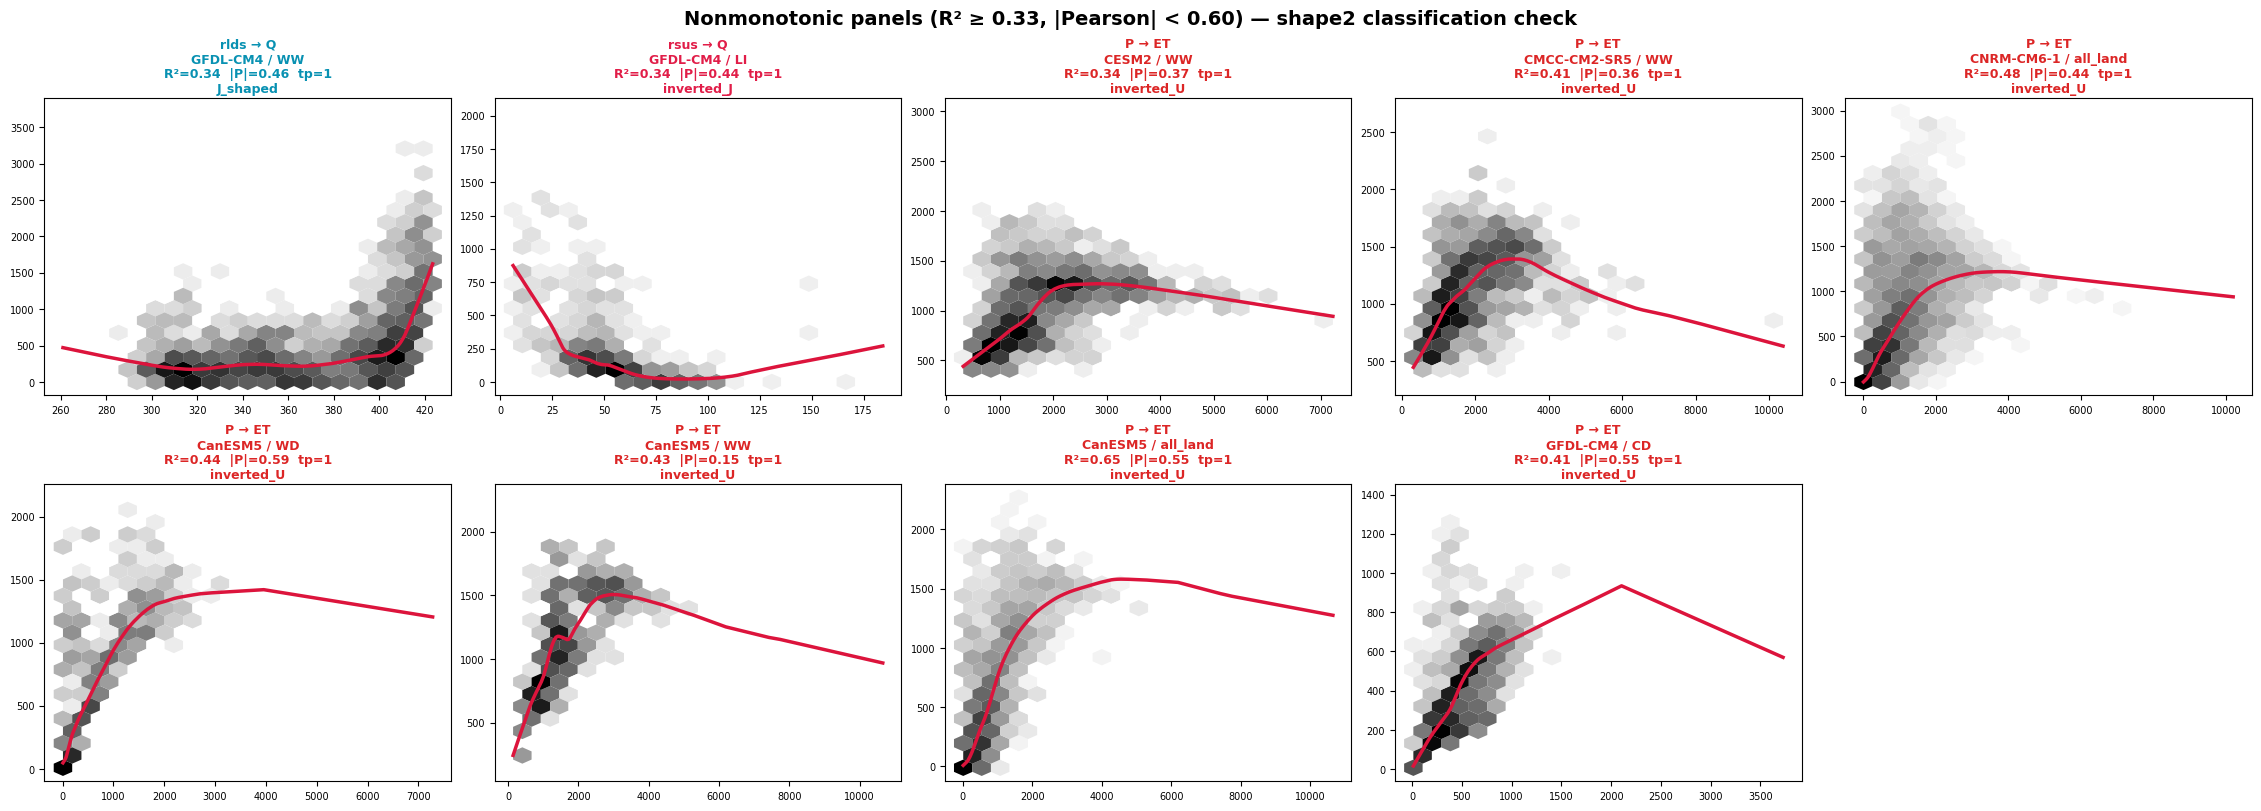

In [47]:
# --- Nonmonotonic panels (R²≥0.33): visual check of shape2 classification ---
_nm = df[(df['lowess_shape'] == 'nonmonotonic') & (df['r2'] >= 0.33)].copy()
_nm = _nm.sort_values(['lowess_shape2', 'Pair', 'Model', 'Zone'])
n_panels = len(_nm)
print(f'Nonmonotonic with R²≥0.33: {n_panels} panels')
print(_nm['lowess_shape2'].value_counts().to_string())

if n_panels > 0:
    ncols = min(5, n_panels)
    nrows = int(np.ceil(n_panels / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.0 * nrows),
                             constrained_layout=True)
    axes = np.atleast_2d(axes)
    if axes.shape[0] == 1 and nrows > 1:
        axes = axes.T

    pair_to_vars = {pl: (xv, yv) for xv, yv, pl in VARIABLE_PAIRS}
    shape2_colors = {
        'U_shaped': '#2563EB', 'inverted_U': '#DC2626',
        'J_shaped': '#0891B2', 'inverted_J': '#E11D48',
        'S_or_N': '#7C3AED', 'complex': '#6B7280',
    }

    for idx, (_, row) in enumerate(_nm.iterrows()):
        ri, ci = divmod(idx, ncols)
        ax = axes[ri, ci]

        pair = row['Pair']
        model = row['Model']
        zone = row['Zone']
        x_var, y_var = pair_to_vars[pair]
        run = next((r for r in runs if r['model'] == model), None)
        if run is None:
            ax.set_visible(False)
            continue

        x, y = get_xy(run, x_var, y_var, zone)
        if x is None:
            ax.set_visible(False)
            continue
        cont = (np.abs(x) > EPS) & (np.abs(y) > EPS)
        xc, yc = x[cont], y[cont]
        if len(xc) < 20:
            ax.set_visible(False)
            continue

        draw_density_hexbin(ax, xc, yc, cmap='Greys', gridsize=20)

        key = (pair, model, zone)
        if key in LOWESS_CURVES:
            xs_c, ys_c = LOWESS_CURVES[key]
            ax.plot(xs_c, ys_c, color='crimson', lw=2.5, zorder=5)

        shape2 = str(row['lowess_shape2'])
        tp = int(row['ls_n_tp'])
        abs_p = row['ls_abs_pearson']
        r2 = row['r2']
        color = shape2_colors.get(shape2, '#333')
        ax.set_title(
            f'{pair}\n{model} / {zone}\n'
            f'R²={r2:.2f}  |P|={abs_p:.2f}  tp={tp}\n'
            f'{shape2}',
            fontsize=9, fontweight='bold', color=color, pad=4,
        )
        ax.tick_params(labelsize=7)

    for idx in range(n_panels, nrows * ncols):
        ri, ci = divmod(idx, ncols)
        axes[ri, ci].set_visible(False)

    fig.suptitle(
        f'Nonmonotonic panels (R² ≥ 0.33, |Pearson| < 0.60) — shape2 classification check',
        fontsize=14, fontweight='semibold')
    _save = OUTPUT_DIR / 'nonmonotonic_shape2_check.png'
    fig.savefig(_save, dpi=150, bbox_inches='tight')
    print(f'Saved: {_save}')
    plt.show()


Panels with R² ≥ 0.35: 121
Manual shape distribution:
manual_shape
Monotonic ↑      106
Non-monotonic      8
Unresolved         3
Flat               3
Monotonic ↓        1


/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_16492/1185527859.py:78: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/output/S4.3_1e-2/pearson_vs_spearman_by_label.png


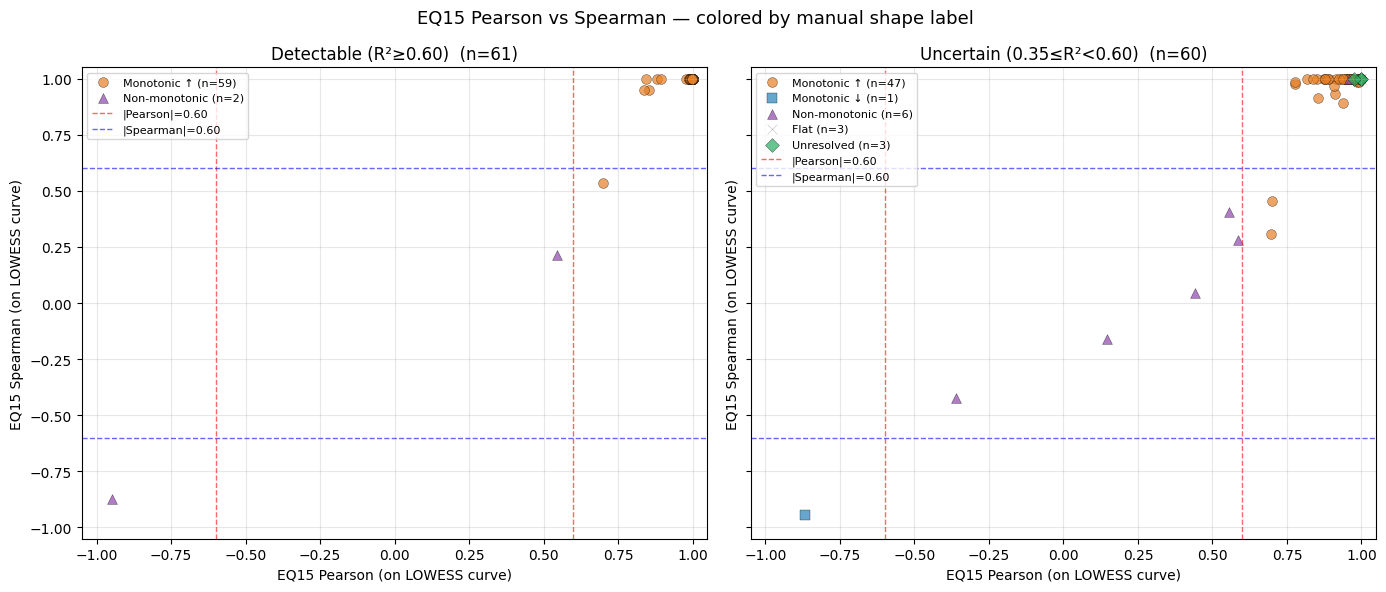

In [58]:
# ── Pearson vs Spearman scatter, colored by manual label ──────────
# Only panels with R² ≥ R2_WEAK (Detectable + Uncertain)
from scipy.stats import spearmanr

records = []
for pair_label in [p[2] for p in VARIABLE_PAIRS]:
    for model in MODELS:
        for zone in ZONES:
            key = (pair_label, model, zone)
            row = lookup.get(key)
            if row is None:
                continue
            r2_val = row.get('r2')
            if r2_val is None or np.isnan(r2_val) or r2_val < R2_WEAK:
                continue
            run = next((r for r in runs if r['model'] == model), None)
            if run is None:
                continue
            x, y = get_xy(run, pair_label.split(' → ')[0],
                          pair_label.split(' → ')[1], zone)
            if x is None or len(x) < 40:
                continue
            finite = np.isfinite(x) & np.isfinite(y)
            xf, yf = x[finite], y[finite]
            r2_class = 'Detectable' if r2_val >= 0.60 else 'Uncertain'
            lw = get_panel_lowess(pair_label, model, zone, xf, yf)
            if lw is None:
                continue
            xs_lw, ys_lw = lw
            n_pts = 15
            x_eq = np.linspace(xf.min(), xf.max(), n_pts)
            y_eq = np.interp(x_eq, xs_lw, ys_lw)
            if np.ptp(y_eq) <= 0:
                continue
            pr = np.corrcoef(x_eq, y_eq)[0, 1]
            sr, _ = spearmanr(x_eq, y_eq)
            manual = _MANUAL_LABELS.get(key)
            m_shape = manual['shape'] if manual else 'na'
            records.append({
                'pair': pair_label, 'model': model, 'zone': zone,
                'r2': r2_val, 'r2_class': r2_class,
                'pearson': pr, 'spearman': sr,
                'manual_shape': m_shape,
            })

df_ps = pd.DataFrame(records)
print(f'Panels with R² ≥ {R2_WEAK}: {len(df_ps)}')
print(f'Manual shape distribution:\n{df_ps["manual_shape"].value_counts().to_string()}')

LABEL_COLORS = {
    'Monotonic ↑': '#E67E22',
    'Monotonic ↓': '#2980B9',
    'Non-monotonic': '#8E44AD',
    'Flat': '#888888',
    'Unresolved': '#27AE60',
    'Insufficient data': '#CCCCCC',
}
LABEL_MARKERS = {
    'Monotonic ↑': 'o',
    'Monotonic ↓': 's',
    'Non-monotonic': '^',
    'Flat': 'x',
    'Unresolved': 'D',
    'Insufficient data': '+',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax_idx, (r2_label, sub) in enumerate([
    ('Detectable (R²≥0.60)', df_ps[df_ps['r2_class'] == 'Detectable']),
    (f'Uncertain ({R2_WEAK}≤R²<0.60)', df_ps[df_ps['r2_class'] == 'Uncertain']),
]):
    ax = axes[ax_idx]
    for shape_label in ['Monotonic ↑', 'Monotonic ↓', 'Non-monotonic', 'Flat', 'Unresolved', 'Insufficient data']:
        mask = sub['manual_shape'] == shape_label
        if mask.sum() == 0:
            continue
        ax.scatter(
            sub.loc[mask, 'pearson'], sub.loc[mask, 'spearman'],
            c=LABEL_COLORS.get(shape_label, '#999'),
            marker=LABEL_MARKERS.get(shape_label, 'o'),
            s=50, alpha=0.7, edgecolors='k', linewidths=0.3,
            label=f'{shape_label} (n={mask.sum()})',
        )
    ax.axvline(0.60, color='red', ls='--', lw=1, alpha=0.6, label='|Pearson|=0.60')
    ax.axvline(-0.60, color='red', ls='--', lw=1, alpha=0.6)
    ax.axhline(0.60, color='blue', ls='--', lw=1, alpha=0.6, label='|Spearman|=0.60')
    ax.axhline(-0.60, color='blue', ls='--', lw=1, alpha=0.6)
    ax.set_xlabel('EQ15 Pearson (on LOWESS curve)')
    ax.set_ylabel('EQ15 Spearman (on LOWESS curve)')
    ax.set_title(f'{r2_label}  (n={len(sub)})')
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)

fig.suptitle('EQ15 Pearson vs Spearman — colored by manual shape label', fontsize=13)
fig.tight_layout()

out_path = OUTPUT_DIR / 'pearson_vs_spearman_by_label.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()


## R² vs amp: Manual label calibration scatter plot

Compare R² (response strength) and amp against manual labels (6 pairs). Operational cuts: **Weak < 0.33**, **Uncertain 0.33–0.60**, **Detectable ≥ 0.60**. Shape is classified for Uncertain and Detectable; Weak / Insufficient skip shape.


In [49]:
# # --- R² vs amp scatter: manual label calibration ---
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import openpyxl

# # ── 1. Load feature table ──
# feat = pd.read_csv('output/S4.3_1e-2/lowess_panel_features.csv')

# # ── 2. Load manual labels from Excel ──
# label_path = 'label/CMIP6_mean_shape_manual_labels.xlsx'
# models = ['CESM2', 'CNRM-CM6-1', 'CanESM5', 'GFDL-CM4', 'CMCC-CM2-SR5']
# zones  = ['all_land', 'WW', 'WD', 'CW', 'CD', 'LI']
# sheets = {
#     'P_Q':     'P → Q',
#     'ET_Q':    'ET → Q',
#     'tran_Q':  'tran → Q',
#     'mrros_Q': 'mrros → Q',
#     'tas_Q':   'tas → Q',
#     'prsn_Q':  'prsn → Q',
# }

# label_map = {}  # (pair, model, zone) -> response label
# for sheet, pair_name in sheets.items():
#     wb = openpyxl.load_workbook(label_path, read_only=True)
#     ws = wb[sheet]
#     for i, m in enumerate(models):
#         for j, z in enumerate(zones):
#             val = ws.cell(5 + i, 2 + j).value
#             if val:
#                 label_map[(pair_name, m, z)] = val
#     wb.close()

# # ── 3. Merge labels into feature table ──
# pairs_to_plot = list(sheets.values())
# df = feat[feat['Pair'].isin(pairs_to_plot)].copy()
# df['manual_label'] = df.apply(
#     lambda r: label_map.get((r['Pair'], r['Model'], r['Zone']), None), axis=1
# )
# df = df.dropna(subset=['manual_label'])
# df = df[df['manual_label'] != 'Insufficient data']

# # ── 4. Plot ──
# fig, ax = plt.subplots(figsize=(9, 6))

# label_style = {
#     'Detectable':  {'c': '#2a78d6', 'marker': 'o', 'alpha': 0.7},
#     'Flat/weak': {'c': '#eb6834', 'marker': 's', 'alpha': 0.6},
#     'Unresolved':  {'c': '#898781', 'marker': '^', 'alpha': 0.7},
# }

# for label, style in label_style.items():
#     sub = df[df['manual_label'] == label]
#     if len(sub) == 0:
#         continue
#     ax.scatter(
#         sub['r2'], sub['amp'],
#         c=style['c'], marker=style['marker'], alpha=style['alpha'],
#         s=50, edgecolors='white', linewidths=0.5,
#         label=f"{label} ({len(sub)})",
#     )

# # Threshold line
# ax.axvline(x=0.33, color='gray', ls='--', lw=1.2, label='R² = 0.33')
# ax.axvline(x=0.60, color='gray', ls=':', lw=1.2, label='R² = 0.60')
# ax.axvspan(0.33, 0.60, color='#F5E6C8', alpha=0.35, zorder=0, label='Uncertain')

# ax.set_xlabel('R²', fontsize=16)
# ax.set_ylabel('amp', fontsize=16)
# ax.set_xlim(-0.2, 1.0)
# ax.set_ylim(0, 10)
# ax.legend(fontsize=16, loc='upper left')
# ax.set_title('R² vs amp — Manual response-strength labels (6 pairs, 180 panels)', fontsize=16)
# ax.tick_params(labelsize=13)
# plt.tight_layout()
# plt.show()

# # ── 5. Summary stats ──
# print('\n── Label counts by pair ──')
# print(df.groupby(['Pair', 'manual_label']).size().unstack(fill_value=0))

# print('\n── R² stats by label ──')
# for label in ['Detectable', 'Flat/weak', 'Unresolved']:
#     sub = df[df['manual_label'] == label]
#     if len(sub) > 0:
#         print(f"  {label:12s}  n={len(sub):3d}  "
#               f"R² = [{sub['r2'].min():.2f}, {sub['r2'].max():.2f}]  "
#               f"median={sub['r2'].median():.2f}")

# # Misclassified at threshold 0.43
# thr = 0.33
# mis = df[
#     ((df['manual_label'] == 'Detectable') & (df['r2'] < thr)) |
#     ((df['manual_label'] == 'Flat/weak') & (df['r2'] >= thr))
# ]
# print(f'\n── Misclassified at R²={thr} ({len(mis)} panels) ──')
# if len(mis) > 0:
#     print(mis[['Pair', 'Model', 'Zone', 'r2', 'amp', 'manual_label']].to_string(index=False))


## R² distribution by manual label — Horizontal violin

Horizontal violin + strip plot showing R² distribution for each manual label category.
Vertical lines at 0.33 and 0.60 mark the operational thresholds.

In [50]:
# # --- R² horizontal violin by manual label ---
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import openpyxl

# # ── 1. Load & merge ──
# feat = pd.read_csv('output/S4.3_1e-2/lowess_panel_features.csv')
# label_path = 'label/CMIP6_mean_shape_manual_labels.xlsx'
# models = ['CESM2', 'CNRM-CM6-1', 'CanESM5', 'GFDL-CM4', 'CMCC-CM2-SR5']
# zones  = ['all_land', 'WW', 'WD', 'CW', 'CD', 'LI']
# sheets = {
#     'P_Q': 'P → Q', 'ET_Q': 'ET → Q', 'tran_Q': 'tran → Q',
#     'mrros_Q': 'mrros → Q', 'tas_Q': 'tas → Q', 'prsn_Q': 'prsn → Q',
# }
# label_map = {}
# for sheet, pair_name in sheets.items():
#     wb = openpyxl.load_workbook(label_path, read_only=True)
#     ws = wb[sheet]
#     for i, m in enumerate(models):
#         for j, z in enumerate(zones):
#             val = ws.cell(5 + i, 2 + j).value
#             if val:
#                 label_map[(pair_name, m, z)] = val
#     wb.close()

# pairs_to_plot = list(sheets.values())
# df = feat[feat['Pair'].isin(pairs_to_plot)].copy()
# df['manual_label'] = df.apply(
#     lambda r: label_map.get((r['Pair'], r['Model'], r['Zone']), None), axis=1
# )
# df = df.dropna(subset=['manual_label', 'r2'])
# df = df[df['manual_label'] != 'Insufficient data']

# # ── 2. Horizontal violin ──
# label_order = ['Detectable', 'Unresolved', 'Flat/weak']
# colors = {'Detectable': '#2a78d6', 'Unresolved': '#898781', 'Flat/weak': '#eb6834'}
# data_by_label = [df[df['manual_label'] == lab]['r2'].values for lab in label_order]

# fig, ax = plt.subplots(figsize=(10, 4))

# parts = ax.violinplot(data_by_label, positions=range(len(label_order)),
#                       vert=False, showmedians=True, showextrema=False)
# for i, (body, lab) in enumerate(zip(parts['bodies'], label_order)):
#     body.set_facecolor(colors[lab])
#     body.set_alpha(0.35)
#     body.set_edgecolor(colors[lab])
# parts['cmedians'].set_color('black')
# parts['cmedians'].set_linewidth(1.5)

# # strip (jittered dots)
# for i, lab in enumerate(label_order):
#     vals = df[df['manual_label'] == lab]['r2'].values
#     jitter = np.random.default_rng(42).uniform(-0.15, 0.15, size=len(vals))
#     ax.scatter(vals, i + jitter, c=colors[lab], s=20, alpha=0.6,
#                edgecolors='white', linewidths=0.3, zorder=3)

# # threshold lines
# ax.axvline(x=0.33, color='gray', ls='--', lw=1.2, label='R² = 0.33')
# ax.axvline(x=0.60, color='gray', ls=':',  lw=1.2, label='R² = 0.60')
# ax.axvspan(0.33, 0.60, color='#F5E6C8', alpha=0.25, zorder=0)

# ax.set_yticks(range(len(label_order)))
# ax.set_yticklabels([f'{lab} ({len(df[df["manual_label"]==lab])})' for lab in label_order],
#                    fontsize=13)
# ax.set_xlabel('R²', fontsize=14)
# ax.set_title('R² distribution by manual label (6 pairs)', fontsize=14)
# ax.legend(fontsize=10, loc='upper right')
# ax.tick_params(labelsize=11)
# ax.set_xlim(-0.25, 1.05)
# plt.tight_layout()
# plt.show()


## R² 阈值敏感性分析

扫描 (low, high) 阈值对，观察 Weak / Uncertain / Detectable 的 panel 数量和占比变化。
如果存在 manual label，同时计算二分类精度（Non-Weak vs Weak）。

=== 当前阈值 (0.35 / 0.60)  总 panel = 510 ===
 low  high  n_weak  n_uncertain  n_detectable  pct_weak  pct_uncertain  pct_detectable
0.35   0.6     387           60            61 75.882353      11.764706       11.960784


/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_16492/1188171301.py:80: UserWarning: Glyph 38408 (\N{CJK UNIFIED IDEOGRAPH-9608}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_16492/1188171301.py:80: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_16492/1188171301.py:80: UserWarning: Glyph 25935 (\N{CJK UNIFIED IDEOGRAPH-654F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_16492/1188171301.py:80: UserWarning: Glyph 24863 (\N{CJK UNIFIED IDEOGRAPH-611F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_16492/1188171301.py:80: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/y6/36h2

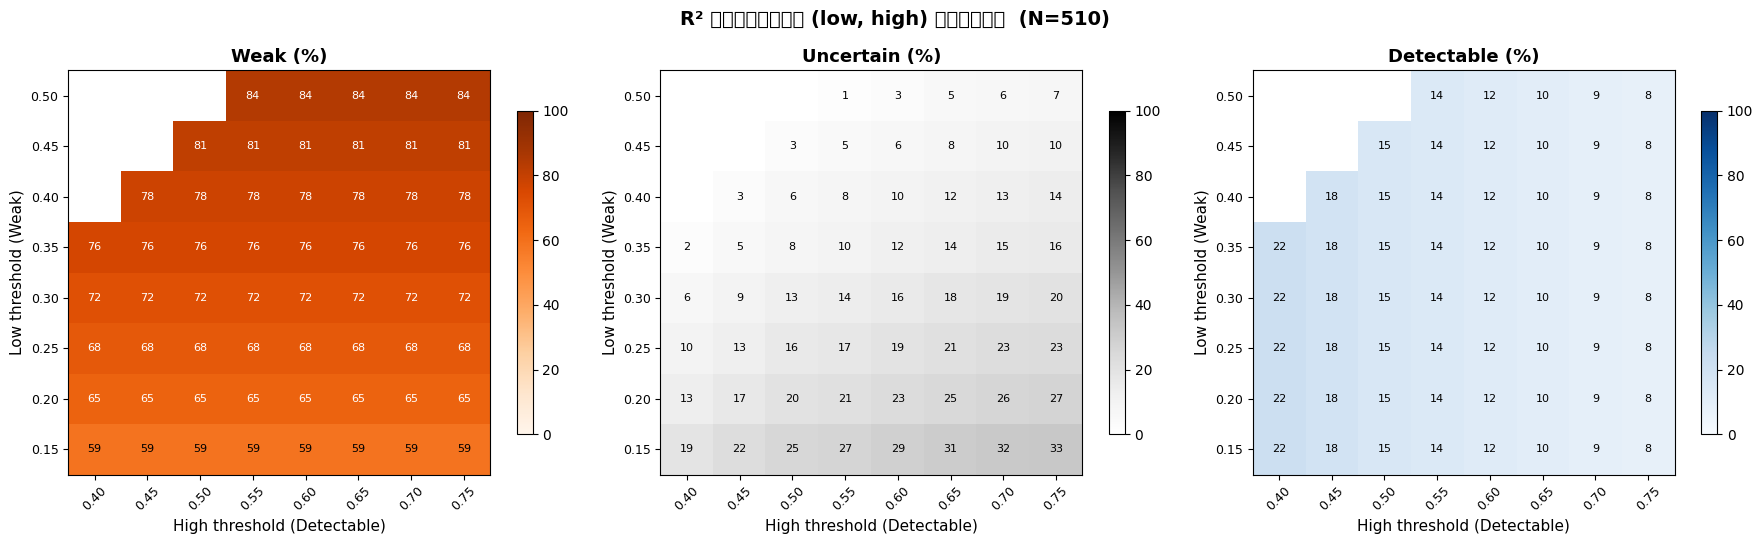

/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_16492/1188171301.py:123: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_16492/1188171301.py:123: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_16492/1188171301.py:123: UserWarning: Glyph 22266 (\N{CJK UNIFIED IDEOGRAPH-56FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_16492/1188171301.py:123: UserWarning: Glyph 23450 (\N{CJK UNIFIED IDEOGRAPH-5B9A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_16492/1188171301.py:123: UserWarning: Glyph 65292 (\N{FULLWIDTH COMMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/y6/36h2pwl51q

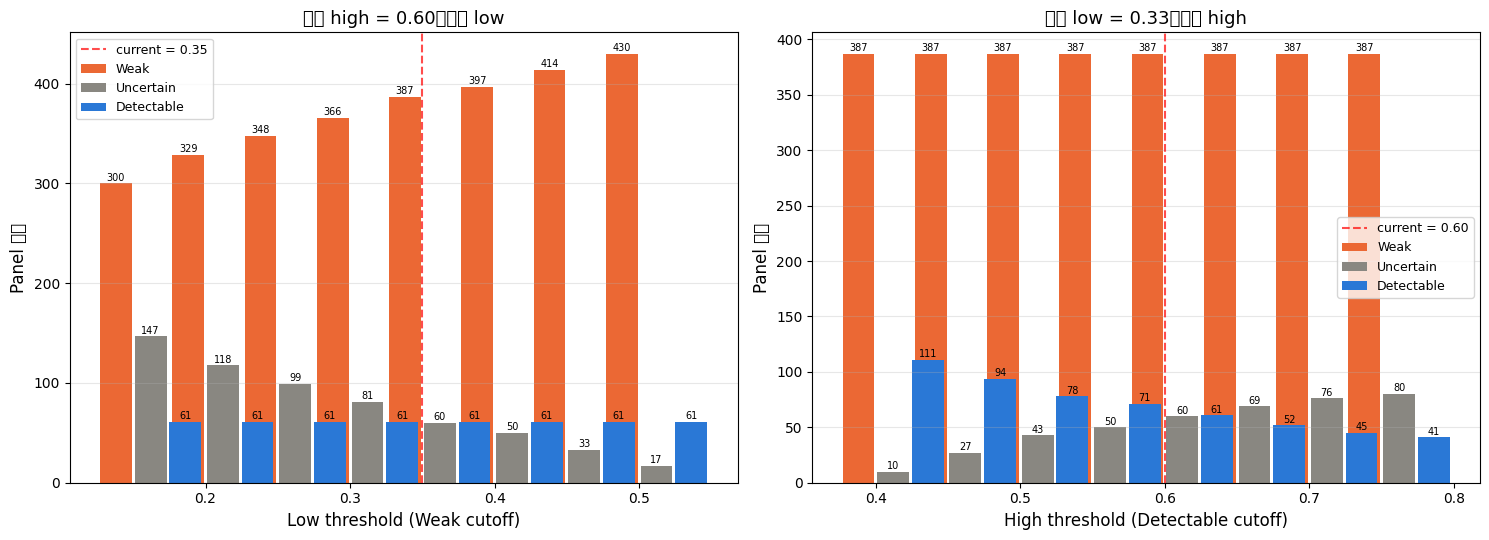


=== 二分类精度 (Non-Weak vs Weak)  有标注: 179 panels ===

 threshold  accuracy  recall_Weak  recall_NonWeak  TP  TN  FP  FN
       0.1      83.2         73.8            97.2  79  70   2  28
       0.2      87.7         81.3            97.2  87  70   2  20
       0.2      88.8         83.2            97.2  89  70   2  18
       0.3      91.6         88.8            95.8  95  69   3  12
       0.3      93.3         92.5            94.4  99  68   4   8
       0.4      93.3         93.5            93.1 100  67   5   7
       0.5      92.2         95.3            87.5 102  63   9   5
       0.5      89.9         97.2            79.2 104  57  15   3


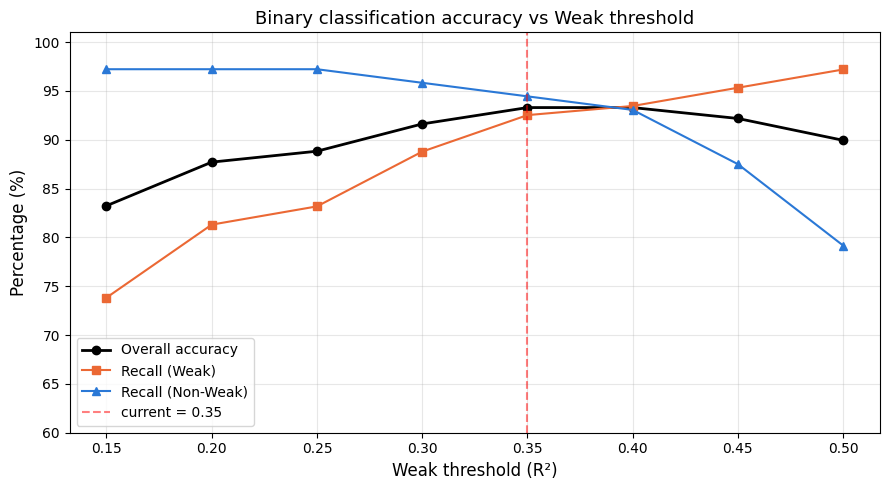

In [51]:
# --- R² 阈值敏感性分析 ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_df = df.copy()
_r2 = _df['r2'].values
n_total = len(_r2)

# ============================================================
#  1. 扫描阈值 — 显式包含当前值 0.33 / 0.60
# ============================================================
low_range  = np.array(sorted(set(
    [round(x, 2) for x in np.arange(0.15, 0.55, 0.05)] + [0.35])))
high_range = np.array(sorted(set(
    [round(x, 2) for x in np.arange(0.40, 0.80, 0.05)] + [0.60])))

rows = []
for lo in low_range:
    for hi in high_range:
        if hi <= lo:
            continue
        n_weak = int(np.sum(_r2 < lo))
        n_unc  = int(np.sum((_r2 >= lo) & (_r2 < hi)))
        n_det  = int(np.sum(_r2 >= hi))
        rows.append({
            'low': round(lo, 4), 'high': round(hi, 4),
            'n_weak': n_weak, 'n_uncertain': n_unc, 'n_detectable': n_det,
            'pct_weak': n_weak / n_total * 100,
            'pct_uncertain': n_unc / n_total * 100,
            'pct_detectable': n_det / n_total * 100,
        })
sweep = pd.DataFrame(rows)

cur = sweep[(np.abs(sweep['low'] - 0.35) < 0.001) &
            (np.abs(sweep['high'] - 0.60) < 0.001)]
if not cur.empty:
    print(f'=== 当前阈值 (0.35 / 0.60)  总 panel = {n_total} ===')
    print(cur[['low','high','n_weak','n_uncertain','n_detectable',
               'pct_weak','pct_uncertain','pct_detectable']].to_string(index=False))

# ============================================================
#  2. 热力图：三类别占比
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, col, title, cmap in zip(
    axes,
    ['pct_weak', 'pct_uncertain', 'pct_detectable'],
    ['Weak (%)', 'Uncertain (%)', 'Detectable (%)'],
    ['Oranges', 'Greys', 'Blues'],
):
    pivot = sweep.pivot(index='low', columns='high', values=col)
    im = ax.imshow(pivot.values, cmap=cmap, aspect='auto', origin='lower',
                   vmin=0, vmax=100)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'{v:.2f}' for v in pivot.columns], fontsize=9, rotation=45)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{v:.2f}' for v in pivot.index], fontsize=9)
    ax.set_xlabel('High threshold (Detectable)', fontsize=11)
    ax.set_ylabel('Low threshold (Weak)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if np.isfinite(val):
                ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                        fontsize=8, color='white' if val > 60 else 'black')
    # 红星标记当前 (0.33, 0.60)
    idx_vals = list(np.round(pivot.index, 4))
    col_vals = list(np.round(pivot.columns, 4))
    if 0.33 in idx_vals and 0.6 in col_vals:
        ci = idx_vals.index(0.33)
        cj = col_vals.index(0.6)
        ax.plot(cj, ci, 'r*', markersize=16, zorder=10)
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle(f'R² 阈值敏感性：不同 (low, high) 下各类别占比  (N={n_total})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
#  3. 单参数扫描 (固定另一个, 看数量+占比)
# ============================================================
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 5.5))

# --- 左图: 固定 high=0.60, 扫描 low ---
sub1 = sweep[np.abs(sweep['high'] - 0.60) < 0.001].sort_values('low')
ax = axes2[0]
ax.bar(sub1['low'] - 0.012, sub1['n_weak'], width=0.022, color='#eb6834', label='Weak')
ax.bar(sub1['low'] + 0.012, sub1['n_uncertain'], width=0.022, color='#898781', label='Uncertain')
ax.bar(sub1['low'] + 0.036, sub1['n_detectable'], width=0.022, color='#2a78d6', label='Detectable')
ax.axvline(0.35, color='red', ls='--', lw=1.5, alpha=0.7, label='current = 0.35')
ax.set_xlabel('Low threshold (Weak cutoff)', fontsize=12)
ax.set_ylabel('Panel 数量', fontsize=12)
ax.set_title('固定 high = 0.60，扫描 low', fontsize=13)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
# 在柱子顶部标数量
for _, r in sub1.iterrows():
    for val, dx in [(r['n_weak'], -0.012), (r['n_uncertain'], 0.012), (r['n_detectable'], 0.036)]:
        if val > 0:
            ax.text(r['low'] + dx, val + 0.5, str(int(val)), ha='center', va='bottom', fontsize=7)

# --- 右图: 固定 low=0.33, 扫描 high ---
sub2 = sweep[np.abs(sweep['low'] - 0.35) < 0.001].sort_values('high')
ax = axes2[1]
ax.bar(sub2['high'] - 0.012, sub2['n_weak'], width=0.022, color='#eb6834', label='Weak')
ax.bar(sub2['high'] + 0.012, sub2['n_uncertain'], width=0.022, color='#898781', label='Uncertain')
ax.bar(sub2['high'] + 0.036, sub2['n_detectable'], width=0.022, color='#2a78d6', label='Detectable')
ax.axvline(0.60, color='red', ls='--', lw=1.5, alpha=0.7, label='current = 0.60')
ax.set_xlabel('High threshold (Detectable cutoff)', fontsize=12)
ax.set_ylabel('Panel 数量', fontsize=12)
ax.set_title('固定 low = 0.33，扫描 high', fontsize=13)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
for _, r in sub2.iterrows():
    for val, dx in [(r['n_weak'], -0.012), (r['n_uncertain'], 0.012), (r['n_detectable'], 0.036)]:
        if val > 0:
            ax.text(r['high'] + dx, val + 0.5, str(int(val)), ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

# ============================================================
#  4. 如果有 manual label, 计算二分类精度
# ============================================================
try:
    import openpyxl
    label_path = 'label/CMIP6_mean_shape_manual_labels.xlsx'
    models = ['CESM2', 'CNRM-CM6-1', 'CanESM5', 'GFDL-CM4', 'CMCC-CM2-SR5']
    zones  = ['all_land', 'WW', 'WD', 'CW', 'CD', 'LI']
    sheets = {
        'P_Q': 'P → Q', 'ET_Q': 'ET → Q', 'tran_Q': 'tran → Q',
        'mrros_Q': 'mrros → Q', 'tas_Q': 'tas → Q', 'prsn_Q': 'prsn → Q',
    }
    label_map = {}
    for sheet, pair_name in sheets.items():
        wb = openpyxl.load_workbook(label_path, read_only=True)
        ws = wb[sheet]
        for i, m in enumerate(models):
            for j, z in enumerate(zones):
                val = ws.cell(5 + i, 2 + j).value
                if val:
                    label_map[(pair_name, m, z)] = val
        wb.close()

    _df['manual_label'] = _df.apply(
        lambda r: label_map.get((r['Pair'], r['Model'], r['Zone']), None), axis=1
    )
    _labeled = _df.dropna(subset=['manual_label', 'r2'])
    _labeled = _labeled[_labeled['manual_label'] != 'Insufficient data']

    if len(_labeled) > 0:
        _labeled = _labeled.copy()
        _labeled['true_weak'] = _labeled['manual_label'] == 'Flat/weak'

        print()
        print(f'=== 二分类精度 (Non-Weak vs Weak)  有标注: {len(_labeled)} panels ===')
        print()

        acc_rows = []
        for lo in low_range:
            pred_weak = _labeled['r2'].values < lo
            true_weak = _labeled['true_weak'].values
            tp = int((true_weak & pred_weak).sum())
            tn = int((~true_weak & ~pred_weak).sum())
            fp = int((~true_weak & pred_weak).sum())
            fn = int((true_weak & ~pred_weak).sum())
            acc = (tp + tn) / len(_labeled) * 100
            recall_w  = tp / max(tp + fn, 1) * 100
            recall_nw = tn / max(tn + fp, 1) * 100
            acc_rows.append({
                'threshold': round(lo, 4),
                'accuracy': acc,
                'recall_Weak': recall_w,
                'recall_NonWeak': recall_nw,
                'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
            })
        acc_df = pd.DataFrame(acc_rows)
        print(acc_df.to_string(index=False, float_format='%.1f'))

        fig3, ax3 = plt.subplots(figsize=(9, 5))
        ax3.plot(acc_df['threshold'], acc_df['accuracy'], 'ko-', lw=2, label='Overall accuracy')
        ax3.plot(acc_df['threshold'], acc_df['recall_Weak'], 's-', color='#eb6834', label='Recall (Weak)')
        ax3.plot(acc_df['threshold'], acc_df['recall_NonWeak'], '^-', color='#2a78d6', label='Recall (Non-Weak)')
        ax3.axvline(0.35, color='red', ls='--', alpha=0.5, label='current = 0.35')
        ax3.set_xlabel('Weak threshold (R²)', fontsize=12)
        ax3.set_ylabel('Percentage (%)', fontsize=12)
        ax3.set_title('Binary classification accuracy vs Weak threshold', fontsize=13)
        ax3.legend(fontsize=10)
        ax3.grid(alpha=0.3)
        ax3.set_ylim(60, 101)
        plt.tight_layout()
        plt.show()
    else:
        print('No valid manual labels found.')
except FileNotFoundError:
    print('Manual label file not found — skipping accuracy analysis.')
except Exception as e:
    print(f'Manual label analysis skipped: {e}')


## N_EQ_PTS 采样点数敏感性分析

扫描不同的 EQ 等距采样点数，观察形状分类（Monotonic / Non-monotonic）与 manual label 的吻合率变化。
R² 和 Weak/Non-Weak 判定不受 N_EQ_PTS 影响（只依赖 LOWESS 拟合值）。

Non-Weak panels with manual label: 115
  Monotonic: 107
  Non-monotonic: 8

 N_EQ_PTS  total  overall_acc  mono_n  mono_recall  nonmono_n  nonmono_recall
        7    115         97.4     107        100.0          8            62.5
        9    115         97.4     107        100.0          8            62.5
       11    115         98.3     107        100.0          8            75.0
       13    115         98.3     107        100.0          8            75.0
       15    115         98.3     107        100.0          8            75.0
       19    115         98.3     107        100.0          8            75.0
       25    115         98.3     107        100.0          8            75.0
       31    115         98.3     107        100.0          8            75.0
       41    115         98.3     107        100.0          8            75.0


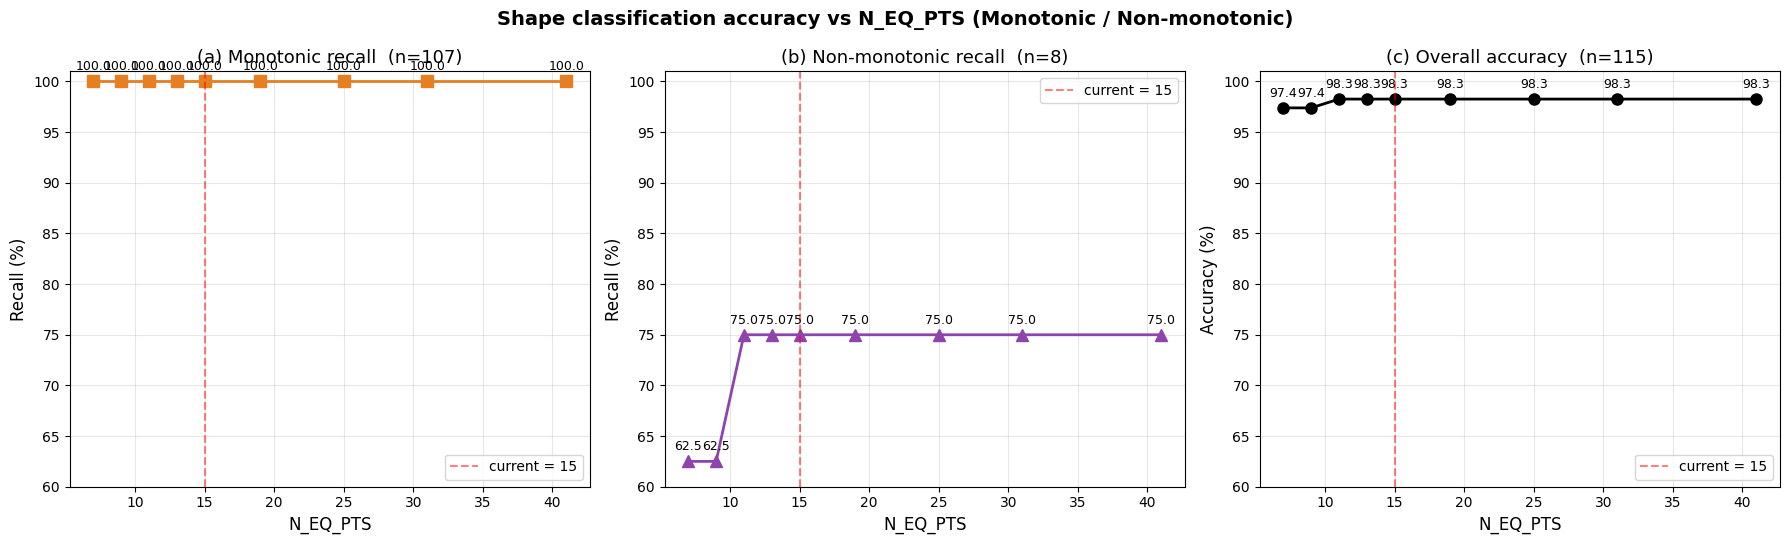

Panels that flip classification across N values: 1


,panel,manual,N=7,N=9,N=11,N=13,N=15,N=19,N=25,N=31,N=41
0,P → ET|CanESM5|WD,Non-monotonic,Monotonic,Monotonic,Non-monotonic,Non-monotonic,Non-monotonic,Non-monotonic,Non-monotonic,Non-monotonic,Non-monotonic


In [60]:
# --- N_EQ_PTS 采样点数敏感性分析 ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import openpyxl

# ============================================================
#  0. 参数
# ============================================================
N_VALUES = [7, 9, 11, 13, 15, 19, 25, 31, 41]
DEADZONE = 0.01
PEARSON_MONO_THRESH = 0.60
BOW_THRESH = 0.15
SYM_THRESH = 0.40

# ============================================================
#  1. 加载 manual label (new xlsx, 全部 17 sheet)
# ============================================================
label_path = CASE_DIR / 'label' / 'CMIP6_mean_shape_manual_labels_new.xlsx'
_sheet_map = {
    'P_Q': 'P → Q', 'ET_Q': 'ET → Q', 'tran_Q': 'tran → Q',
    'mrros_Q': 'mrros → Q', 'tas_Q': 'tas → Q', 'prsn_Q': 'prsn → Q',
    'evspsblsoi_Q': 'evspsblsoi → Q', 'hfls_Q': 'hfls → Q',
    'hfss_Q': 'hfss → Q', 'lai_Q': 'lai → Q', 'rsds_Q': 'rsds → Q',
    'mrso_Q': 'mrso → Q', 'mrsos_Q': 'mrsos → Q', 'rlds_Q': 'rlds → Q',
    'rlus_Q': 'rlus → Q', 'rsus_Q': 'rsus → Q', 'P_ET': 'P → ET',
}
_label_map = {}
wb = openpyxl.load_workbook(str(label_path), data_only=True)
for sn in wb.sheetnames:
    if sn not in _sheet_map:
        continue
    pl = _sheet_map[sn]
    ws = wb[sn]
    for i, m in enumerate(MODELS):
        for j, z in enumerate(ZONES):
            shape_val = str(ws.cell(14 + i, 2 + j).value).strip()
            if shape_val and shape_val != 'None':
                _label_map[(pl, m, z)] = shape_val
wb.close()

# manual label -> binary: Monotonic vs Non-monotonic
def _manual_to_binary(label):
    if label in ('Monotonic ↑', 'Monotonic ↓'):
        return 'Monotonic'
    elif label in ('Non-monotonic',):
        return 'Non-monotonic'
    return None

# ============================================================
#  2. 收集 Non-Weak panels (有 LOWESS 曲线 + manual label)
# ============================================================
panels = []
for _, row in df.iterrows():
    r2_val = row.get('r2')
    if r2_val is None or np.isnan(r2_val) or r2_val < R2_WEAK:
        continue
    key = (row['Pair'], row['Model'], row['Zone'])
    manual_raw = _label_map.get(key)
    if manual_raw is None:
        continue
    manual_bin = _manual_to_binary(manual_raw)
    if manual_bin is None:
        continue
    lw = LOWESS_CURVES.get(key)
    if lw is None:
        continue
    xs_lw, ys_lw = lw
    run = next((r for r in runs if r['model'] == row['Model']), None)
    if run is None:
        continue
    xvar = row['Pair'].split(' → ')[0]
    yvar = row['Pair'].split(' → ')[1]
    x_raw, y_raw = get_xy(run, xvar, yvar, row['Zone'])
    if x_raw is None:
        continue
    finite = np.isfinite(x_raw) & np.isfinite(y_raw)
    xf, yf = x_raw[finite], y_raw[finite]
    if len(xf) < 50:
        continue
    panels.append({
        'key': key,
        'xf': xf, 'yf': yf,
        'xs': xs_lw, 'ys': ys_lw,
        'manual_raw': manual_raw,
        'manual_bin': manual_bin,
    })

print(f'Non-Weak panels with manual label: {len(panels)}')
print(f'  Monotonic: {sum(1 for p in panels if p["manual_bin"]=="Monotonic")}')
print(f'  Non-monotonic: {sum(1 for p in panels if p["manual_bin"]=="Non-monotonic")}')

# ============================================================
#  3. 对每个 N_EQ_PTS 重新分类
# ============================================================
def _classify_shape(xf, yf, xs, ys, n_pts):
    x_eq = np.linspace(xf.min(), xf.max(), n_pts)
    y_eq = np.interp(x_eq, xs, ys)
    if np.ptp(y_eq) <= 0:
        return 'skip', None
    pr = float(np.corrcoef(x_eq, y_eq)[0, 1])
    if abs(pr) >= PEARSON_MONO_THRESH:
        return 'Monotonic', pr
    return 'Non-monotonic', pr

results = {}  # n_pts -> list of (predicted_bin, pearson)
for n in N_VALUES:
    preds = []
    for p in panels:
        pred_bin, pr = _classify_shape(p['xf'], p['yf'], p['xs'], p['ys'], n)
        preds.append({
            'key': p['key'],
            'manual_bin': p['manual_bin'],
            'manual_raw': p['manual_raw'],
            'pred_bin': pred_bin,
            'pearson': pr,
        })
    results[n] = preds

# ============================================================
#  4. 计算精度
# ============================================================
acc_rows = []
for n in N_VALUES:
    preds = [p for p in results[n] if p['pred_bin'] != 'skip']
    total = len(preds)
    correct_all = sum(1 for p in preds if p['pred_bin'] == p['manual_bin'])

    mono_true = [p for p in preds if p['manual_bin'] == 'Monotonic']
    mono_correct = sum(1 for p in mono_true if p['pred_bin'] == 'Monotonic')

    nonmono_true = [p for p in preds if p['manual_bin'] == 'Non-monotonic']
    nonmono_correct = sum(1 for p in nonmono_true if p['pred_bin'] == 'Non-monotonic')

    acc_rows.append({
        'N_EQ_PTS': n,
        'total': total,
        'overall_acc': correct_all / max(total, 1) * 100,
        'mono_n': len(mono_true),
        'mono_recall': mono_correct / max(len(mono_true), 1) * 100,
        'nonmono_n': len(nonmono_true),
        'nonmono_recall': nonmono_correct / max(len(nonmono_true), 1) * 100,
    })

acc_df = pd.DataFrame(acc_rows)
print()
print(acc_df.to_string(index=False, float_format='%.1f'))

# ============================================================
#  5. 三个精度图
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# --- (a) Monotonic recall ---
ax = axes[0]
ax.plot(acc_df['N_EQ_PTS'], acc_df['mono_recall'], 's-', color='#E67E22', lw=2, markersize=8)
ax.axvline(15, color='red', ls='--', alpha=0.5, label='current = 15')
ax.set_xlabel('N_EQ_PTS', fontsize=12)
ax.set_ylabel('Recall (%)', fontsize=12)
ax.set_title(f'(a) Monotonic recall  (n={acc_df["mono_n"].iloc[0]})', fontsize=13)
ax.set_ylim(60, 101)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
for _, r in acc_df.iterrows():
    ax.text(r['N_EQ_PTS'], r['mono_recall'] + 0.8, f'{r["mono_recall"]:.1f}',
            ha='center', va='bottom', fontsize=9)

# --- (b) Non-monotonic recall ---
ax = axes[1]
ax.plot(acc_df['N_EQ_PTS'], acc_df['nonmono_recall'], '^-', color='#8E44AD', lw=2, markersize=8)
ax.axvline(15, color='red', ls='--', alpha=0.5, label='current = 15')
ax.set_xlabel('N_EQ_PTS', fontsize=12)
ax.set_ylabel('Recall (%)', fontsize=12)
ax.set_title(f'(b) Non-monotonic recall  (n={acc_df["nonmono_n"].iloc[0]})', fontsize=13)
ax.set_ylim(60, 101)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
for _, r in acc_df.iterrows():
    ax.text(r['N_EQ_PTS'], r['nonmono_recall'] + 0.8, f'{r["nonmono_recall"]:.1f}',
            ha='center', va='bottom', fontsize=9)

# --- (c) Overall accuracy ---
ax = axes[2]
ax.plot(acc_df['N_EQ_PTS'], acc_df['overall_acc'], 'ko-', lw=2, markersize=8)
ax.axvline(15, color='red', ls='--', alpha=0.5, label='current = 15')
ax.set_xlabel('N_EQ_PTS', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title(f'(c) Overall accuracy  (n={acc_df["total"].iloc[0]})', fontsize=13)
ax.set_ylim(60, 101)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
for _, r in acc_df.iterrows():
    ax.text(r['N_EQ_PTS'], r['overall_acc'] + 0.8, f'{r["overall_acc"]:.1f}',
            ha='center', va='bottom', fontsize=9)

fig.suptitle('Shape classification accuracy vs N_EQ_PTS (Monotonic / Non-monotonic)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
#  6. 翻转 panel 热力图
# ============================================================
# 找出在不同 N 下分类不一致的 panel
flip_data = {}
for n in N_VALUES:
    for p in results[n]:
        k = p['key']
        if k not in flip_data:
            flip_data[k] = {'manual': p['manual_bin'], 'preds': {}}
        flip_data[k]['preds'][n] = p['pred_bin']

flipped = {k: v for k, v in flip_data.items()
           if len(set(v['preds'].values()) - {'skip'}) > 1}

if flipped:
    print(f'Panels that flip classification across N values: {len(flipped)}')
    flip_rows = []
    for k, v in sorted(flipped.items()):
        row = {'panel': f'{k[0]}|{k[1]}|{k[2]}', 'manual': v['manual']}
        for n in N_VALUES:
            row[f'N={n}'] = v['preds'].get(n, '?')
        flip_rows.append(row)
    flip_df = pd.DataFrame(flip_rows)
    display(flip_df)
else:
    print('No panels flip classification across different N values.')


## R² distribution by manual label — KDE overlay

Overlapping density curves for each manual label. The crossover points
between Flat/weak and Detectable densities suggest natural threshold positions.

## Threshold sensitivity analysis

Sweep (low, high) threshold pairs and compute purity of the two confident zones.
Find the Pareto front balancing purity vs uncertain-band width.

## Pearson vs Spearman vs R² vs MIC — Manual label calibration

Four scatter plots comparing raw Pearson r, raw Spearman ρ, LOWESS R², and MIC,
coloured by manual response-strength labels (6 pairs).

In [52]:
# # --- Pearson vs Spearman vs R² vs MIC: manual label calibration ---
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import openpyxl

# # ── 1. Load feature table ──
# feat = pd.read_csv('output/S4.3_1e-2/lowess_panel_features.csv')

# # ── 2. Load manual labels from Excel ──
# label_path = 'label/CMIP6_mean_shape_manual_labels.xlsx'
# models = ['CESM2', 'CNRM-CM6-1', 'CanESM5', 'GFDL-CM4', 'CMCC-CM2-SR5']
# zones  = ['all_land', 'WW', 'WD', 'CW', 'CD', 'LI']
# sheets = {
#     'P_Q':     'P → Q',
#     'ET_Q':    'ET → Q',
#     'tran_Q':  'tran → Q',
#     'mrros_Q': 'mrros → Q',
#     'tas_Q':   'tas → Q',
#     'prsn_Q':  'prsn → Q',
# }

# label_map = {}
# for sheet, pair_name in sheets.items():
#     wb = openpyxl.load_workbook(label_path, read_only=True)
#     ws = wb[sheet]
#     for i, m in enumerate(models):
#         for j, z in enumerate(zones):
#             val = ws.cell(5 + i, 2 + j).value
#             if val:
#                 label_map[(pair_name, m, z)] = val
#     wb.close()

# # ── 3. Merge labels ──
# pairs_to_plot = list(sheets.values())
# df = feat[feat['Pair'].isin(pairs_to_plot)].copy()
# df['manual_label'] = df.apply(
#     lambda r: label_map.get((r['Pair'], r['Model'], r['Zone']), None), axis=1
# )
# df = df.dropna(subset=['manual_label'])
# df = df[df['manual_label'] != 'Insufficient data']

# # ── 4. Plot 4 subplots ──
# label_style = {
#     'Detectable':  {'c': '#2a78d6', 'marker': 'o', 'alpha': 0.7},
#     'Flat/weak':   {'c': '#eb6834', 'marker': 's', 'alpha': 0.6},
#     'Unresolved':  {'c': '#898781', 'marker': '^', 'alpha': 0.7},
# }

# panels = [
#     ('r2',        'pearson_r',  'R²',        'Pearson r'),
#     ('r2',        'spearman_r', 'R²',        'Spearman ρ'),
#     ('pearson_r', 'spearman_r', 'Pearson r',  'Spearman ρ'),
#     ('r2',        'mic',        'R²',        'MIC'),
# ]

# fig, axes = plt.subplots(2, 2, figsize=(14, 12))
# axes = axes.ravel()

# for ax, (xcol, ycol, xlab, ylab) in zip(axes, panels):
#     for label, style in label_style.items():
#         sub = df[df['manual_label'] == label].dropna(subset=[xcol, ycol])
#         if len(sub) == 0:
#             continue
#         ax.scatter(
#             sub[xcol], sub[ycol],
#             c=style['c'], marker=style['marker'], alpha=style['alpha'],
#             s=50, edgecolors='white', linewidths=0.5,
#             label=f"{label} ({len(sub)})",
#         )
#     # 1:1 reference line
#     lo = min(ax.get_xlim()[0], ax.get_ylim()[0])
#     hi = max(ax.get_xlim()[1], ax.get_ylim()[1])
#     ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.4, label='1:1')
#     ax.set_xlabel(xlab, fontsize=14)
#     ax.set_ylabel(ylab, fontsize=14)
#     ax.legend(fontsize=9, loc='upper left')
#     ax.tick_params(labelsize=11)
#     ax.set_title(f'{xlab} vs {ylab}', fontsize=14)

# fig.suptitle('Pearson / Spearman / R² / MIC — Manual labels (6 pairs)', fontsize=16)
# plt.tight_layout()
# plt.show()

# # ── 5. Correlation between metrics ──
# print('\n── Metric correlations (Pearson) ──')
# for a, b in [('r2', 'pearson_r'), ('r2', 'spearman_r'), ('pearson_r', 'spearman_r'), ('r2', 'mic')]:
#     valid = df[[a, b]].dropna()
#     r = valid[a].corr(valid[b])
#     print(f'  {a:12s} vs {b:12s}  r = {r:.3f}  (n={len(valid)})')


## Threshold classification accuracy (R² = 0.3 / 0.6)

Map R² to predicted labels via two thresholds, then compare with manual labels.
Also test Pearson and Spearman with the same thresholds for comparison.

In [53]:
# # --- Threshold classification accuracy ---
# from sklearn.metrics import confusion_matrix, classification_report

# def classify_by_thresholds(values, lo, hi):
#     """Map continuous metric to Flat/weak | Unresolved | Detectable."""
#     out = []
#     for v in values:
#         if np.isnan(v):
#             out.append(None)
#         elif v < lo:
#             out.append('Flat/weak')
#         elif v < hi:
#             out.append('Unresolved')
#         else:
#             out.append('Detectable')
#     return out

# label_order = ['Flat/weak', 'Unresolved', 'Detectable']

# metrics_to_test = [
#     ('R²',        'r2',         0.33, 0.60),
#     ('Pearson r', 'pearson_r',  0.33, 0.60),
#     ('Spearman ρ','spearman_r', 0.33, 0.60),
#     ('MIC',       'mic',        0.33, 0.60),
# ]

# for name, col, lo, hi in metrics_to_test:
#     valid = df.dropna(subset=[col]).copy()
#     valid['pred'] = classify_by_thresholds(valid[col].values, lo, hi)
#     y_true = valid['manual_label']
#     y_pred = valid['pred']
#     acc = (y_true == y_pred).mean()
#     print(f'\n{"="*60}')
#     print(f'{name}  thresholds = ({lo}, {hi})  accuracy = {acc:.1%}  (n={len(valid)})')
#     print(f'{"="*60}')
#     print(classification_report(y_true, y_pred, labels=label_order, zero_division=0))
#     cm = confusion_matrix(y_true, y_pred, labels=label_order)
#     print('Confusion matrix (rows=true, cols=pred):')
#     print(pd.DataFrame(cm, index=label_order, columns=label_order))


## R² distribution — Updated manual labels (new Excel)

Same violin + strip as above, but reading from `CMIP6_mean_shape_manual_labels_new.xlsx`.
Covers all sheets that have response-strength labels filled in.

Pairs with labels: ['ET → Q', 'P → ET', 'P → Q', 'evspsblsoi → Q', 'hfls → Q', 'hfss → Q', 'lai → Q', 'mrros → Q', 'mrso → Q', 'mrsos → Q', 'prsn → Q', 'rlds → Q', 'rlus → Q', 'rsds → Q', 'rsus → Q', 'tas → Q', 'tran → Q']
Total labelled panels: 508
manual_label
Flat/weak     359
Detectable    110
Unresolved     39


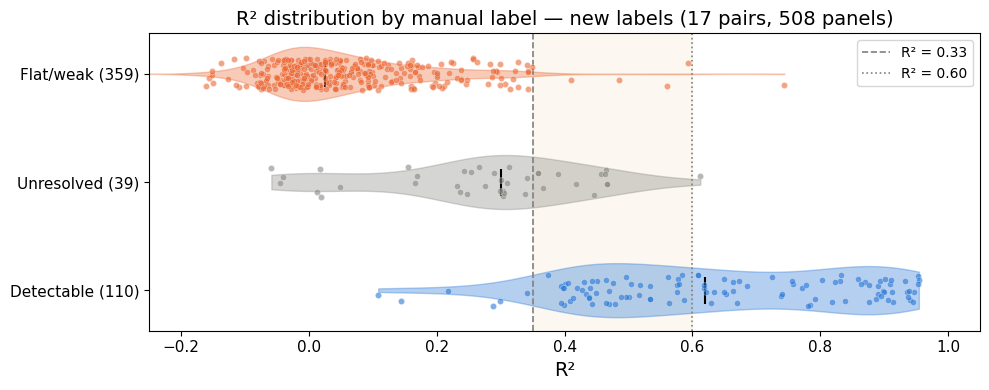

  R² < 0.35    n=387  (Detectable=6, Unresolved=27, Flat/weak=354)
  R² 0.35–0.60  n= 60  (Detectable=45, Unresolved=11, Flat/weak=4)
  R² ≥ 0.60    n= 61  (Detectable=59, Unresolved=1, Flat/weak=1)


In [54]:
# --- R² violin: updated manual labels (new Excel) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl

# ── 1. Load feature table ──
feat = pd.read_csv('output/S4.3_1e-2/lowess_panel_features.csv')

# ── 2. Load NEW manual labels ──
label_path_new = 'label/CMIP6_mean_shape_manual_labels_new.xlsx'
models = ['CESM2', 'CNRM-CM6-1', 'CanESM5', 'GFDL-CM4', 'CMCC-CM2-SR5']
zones  = ['all_land', 'WW', 'WD', 'CW', 'CD', 'LI']

# All sheets with pair mapping
all_sheets = {
    'P_Q': 'P → Q', 'ET_Q': 'ET → Q', 'tran_Q': 'tran → Q',
    'mrros_Q': 'mrros → Q', 'tas_Q': 'tas → Q', 'prsn_Q': 'prsn → Q',
    'evspsblsoi_Q': 'evspsblsoi → Q', 'hfls_Q': 'hfls → Q',
    'hfss_Q': 'hfss → Q', 'lai_Q': 'lai → Q', 'rsds_Q': 'rsds → Q',
    'mrso_Q': 'mrso → Q', 'mrsos_Q': 'mrsos → Q',
    'rlds_Q': 'rlds → Q', 'rlus_Q': 'rlus → Q', 'rsus_Q': 'rsus → Q',
    'P_ET': 'P → ET',
}

label_map = {}
wb = openpyxl.load_workbook(label_path_new, read_only=True)
for sheet, pair_name in all_sheets.items():
    if sheet not in wb.sheetnames:
        continue
    ws = wb[sheet]
    for i, m in enumerate(models):
        for j, z in enumerate(zones):
            val = ws.cell(5 + i, 2 + j).value
            if val and val.strip():
                label_map[(pair_name, m, z)] = val.strip()
wb.close()

# ── 3. Merge ──
pairs_with_labels = sorted(set(p for (p, _, _) in label_map.keys()))
df = feat[feat['Pair'].isin(pairs_with_labels)].copy()
df['manual_label'] = df.apply(
    lambda r: label_map.get((r['Pair'], r['Model'], r['Zone']), None), axis=1
)
df = df.dropna(subset=['manual_label', 'r2'])
df = df[df['manual_label'] != 'Insufficient data']

print(f'Pairs with labels: {pairs_with_labels}')
print(f'Total labelled panels: {len(df)}')
print(df['manual_label'].value_counts().to_string())

# ── 4. Horizontal violin ──
label_order = ['Detectable', 'Unresolved', 'Flat/weak']
colors = {'Detectable': '#2a78d6', 'Unresolved': '#898781', 'Flat/weak': '#eb6834'}
data_by_label = [df[df['manual_label'] == lab]['r2'].values for lab in label_order]

fig, ax = plt.subplots(figsize=(10, 4))

parts = ax.violinplot(data_by_label, positions=range(len(label_order)),
                      vert=False, showmedians=True, showextrema=False)
for i, (body, lab) in enumerate(zip(parts['bodies'], label_order)):
    body.set_facecolor(colors[lab])
    body.set_alpha(0.35)
    body.set_edgecolor(colors[lab])
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(1.5)

# strip (jittered dots)
for i, lab in enumerate(label_order):
    vals = df[df['manual_label'] == lab]['r2'].values
    jitter = np.random.default_rng(42).uniform(-0.15, 0.15, size=len(vals))
    ax.scatter(vals, i + jitter, c=colors[lab], s=20, alpha=0.6,
               edgecolors='white', linewidths=0.3, zorder=3)

# threshold lines
ax.axvline(x=0.35, color='gray', ls='--', lw=1.2, label='R² = 0.33')
ax.axvline(x=0.60, color='gray', ls=':',  lw=1.2, label='R² = 0.60')
ax.axvspan(0.35, 0.60, color='#F5E6C8', alpha=0.25, zorder=0)

ax.set_yticks(range(len(label_order)))
ax.set_yticklabels([f'{lab} ({len(df[df["manual_label"]==lab])})' for lab in label_order],
                   fontsize=13)
ax.set_xlabel('R²', fontsize=14)
n_pairs = len(pairs_with_labels)
ax.set_title(f'R² distribution by manual label — new labels ({n_pairs} pairs, {len(df)} panels)',
             fontsize=14)
ax.legend(fontsize=10, loc='upper right')
ax.tick_params(labelsize=11)
ax.set_xlim(-0.25, 1.05)
plt.tight_layout()
plt.show()

# ── 5. Zone purity ──
for lo, hi, zone_name in [(None, 0.35, '< 0.35'), (0.35, 0.60, '0.35–0.60'), (0.60, None, '≥ 0.60')]:
    mask = pd.Series(True, index=df.index)
    if lo is not None: mask &= df['r2'] >= lo
    if hi is not None: mask &= df['r2'] < hi
    sub = df[mask]
    counts = sub['manual_label'].value_counts()
    total = len(sub)
    parts_str = ', '.join(f'{lab}={counts.get(lab,0)}' for lab in label_order)
    print(f'  R² {zone_name:8s}  n={total:3d}  ({parts_str})')


## R² vs Pearson r — Side-by-side violin by manual label

Compare how well R² and Pearson r separate the three label categories.

In [55]:
# # --- R² vs Pearson r: side-by-side violin ---
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import openpyxl

# # ── 1. Load & merge ──
# feat = pd.read_csv('output/S4.3_1e-2/lowess_panel_features.csv')
# label_path = 'label/CMIP6_mean_shape_manual_labels.xlsx'
# models = ['CESM2', 'CNRM-CM6-1', 'CanESM5', 'GFDL-CM4', 'CMCC-CM2-SR5']
# zones  = ['all_land', 'WW', 'WD', 'CW', 'CD', 'LI']
# sheets = {
#     'P_Q': 'P → Q', 'ET_Q': 'ET → Q', 'tran_Q': 'tran → Q',
#     'mrros_Q': 'mrros → Q', 'tas_Q': 'tas → Q', 'prsn_Q': 'prsn → Q',
# }
# label_map = {}
# for sheet, pair_name in sheets.items():
#     wb = openpyxl.load_workbook(label_path, read_only=True)
#     ws = wb[sheet]
#     for i, m in enumerate(models):
#         for j, z in enumerate(zones):
#             val = ws.cell(5 + i, 2 + j).value
#             if val:
#                 label_map[(pair_name, m, z)] = val
#     wb.close()

# df = feat[feat['Pair'].isin(sheets.values())].copy()
# df['manual_label'] = df.apply(
#     lambda r: label_map.get((r['Pair'], r['Model'], r['Zone']), None), axis=1
# )
# df = df.dropna(subset=['manual_label', 'r2', 'pearson_r'])
# df = df[df['manual_label'] != 'Insufficient data']

# # ── 2. Side-by-side violin ──
# label_order = ['Detectable', 'Unresolved', 'Flat/weak']
# colors = {'Detectable': '#2a78d6', 'Unresolved': '#898781', 'Flat/weak': '#eb6834'}

# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharey=True)

# for ax, col, title, lo_thr in [(ax1, 'r2', 'R²', 0.33), (ax2, 'pearson_r', 'Pearson r', 0.33)]:
#     data = [df[df['manual_label'] == lab][col].values for lab in label_order]
#     parts = ax.violinplot(data, positions=range(len(label_order)),
#                           vert=False, showmedians=True, showextrema=False)
#     for i, (body, lab) in enumerate(zip(parts['bodies'], label_order)):
#         body.set_facecolor(colors[lab])
#         body.set_alpha(0.35)
#         body.set_edgecolor(colors[lab])
#     parts['cmedians'].set_color('black')
#     parts['cmedians'].set_linewidth(1.5)

#     for i, lab in enumerate(label_order):
#         vals = df[df['manual_label'] == lab][col].values
#         jitter = np.random.default_rng(42).uniform(-0.15, 0.15, size=len(vals))
#         ax.scatter(vals, i + jitter, c=colors[lab], s=18, alpha=0.55,
#                    edgecolors='white', linewidths=0.3, zorder=3)

#     ax.axvline(x=lo_thr, color='gray', ls='--', lw=1.2, label=f'{title} = {lo_thr}')
#     ax.axvline(x=0.60, color='gray', ls=':',  lw=1.2, label=f'{title} = 0.60')
#     ax.axvspan(lo_thr, 0.60, color='#F5E6C8', alpha=0.25, zorder=0)

#     ax.set_yticks(range(len(label_order)))
#     ax.set_yticklabels([f'{lab} ({len(df[df["manual_label"]==lab])})' for lab in label_order],
#                        fontsize=12)
#     ax.set_xlabel(title, fontsize=13)
#     ax.set_title(title, fontsize=14)
#     ax.legend(fontsize=9, loc='upper right')
#     ax.tick_params(labelsize=10)
#     ax.set_xlim(-0.5, 1.05)

# fig.suptitle('R² vs Pearson r — distribution by manual label (6 pairs)', fontsize=15, y=1.02)
# plt.tight_layout()
# plt.show()


## Pearson r distribution where R² > 0.33 — by manual label

In [56]:
# # --- Pearson r violin for R² > 0.33, by manual label ---
# import pandas as pd, numpy as np, matplotlib.pyplot as plt, openpyxl

# feat = pd.read_csv('output/S4.3_1e-2/lowess_panel_features.csv')
# label_path = 'label/CMIP6_mean_shape_manual_labels.xlsx'
# models = ['CESM2', 'CNRM-CM6-1', 'CanESM5', 'GFDL-CM4', 'CMCC-CM2-SR5']
# zones  = ['all_land', 'WW', 'WD', 'CW', 'CD', 'LI']
# sheets = {
#     'P_Q': 'P → Q', 'ET_Q': 'ET → Q', 'tran_Q': 'tran → Q',
#     'mrros_Q': 'mrros → Q', 'tas_Q': 'tas → Q', 'prsn_Q': 'prsn → Q',
# }
# label_map = {}
# for sheet, pair_name in sheets.items():
#     wb = openpyxl.load_workbook(label_path, read_only=True)
#     ws = wb[sheet]
#     for i, m in enumerate(models):
#         for j, z in enumerate(zones):
#             val = ws.cell(5 + i, 2 + j).value
#             if val:
#                 label_map[(pair_name, m, z)] = val
#     wb.close()

# df = feat[feat['Pair'].isin(sheets.values())].copy()
# df['manual_label'] = df.apply(
#     lambda r: label_map.get((r['Pair'], r['Model'], r['Zone']), None), axis=1
# )
# df = df.dropna(subset=['manual_label', 'r2', 'pearson_r'])
# df = df[df['manual_label'] != 'Insufficient data']
# sub = df[df['r2'] > 0.33].copy()

# label_order = ['Detectable', 'Unresolved', 'Flat/weak']
# colors = {'Detectable': '#2a78d6', 'Unresolved': '#898781', 'Flat/weak': '#eb6834'}

# fig, ax = plt.subplots(figsize=(10, 4.5))

# data = [sub[sub['manual_label'] == lab]['pearson_r'].values for lab in label_order]
# parts = ax.violinplot(data, positions=range(len(label_order)),
#                       vert=False, showmedians=True, showextrema=False)
# for body, lab in zip(parts['bodies'], label_order):
#     body.set_facecolor(colors[lab])
#     body.set_alpha(0.35)
#     body.set_edgecolor(colors[lab])
# parts['cmedians'].set_color('black')
# parts['cmedians'].set_linewidth(1.5)

# for i, lab in enumerate(label_order):
#     vals = sub[sub['manual_label'] == lab]['pearson_r'].values
#     jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(vals))
#     ax.scatter(vals, i + jitter, c=colors[lab], s=20, alpha=0.55,
#                edgecolors='white', linewidths=0.3, zorder=3)

# ax.set_yticks(range(len(label_order)))
# ax.set_yticklabels([f'{lab} (n={len(d)})' for lab, d in zip(label_order, data)],
#                     fontsize=12)
# ax.set_xlabel('Pearson r', fontsize=13)
# ax.set_title('Pearson r distribution (R² > 0.33) by manual label', fontsize=14)
# ax.set_xlim(0, 1.05)
# ax.tick_params(labelsize=10)

# for lab, d in zip(label_order, data):
#     if len(d):
#         print(f'{lab:12s}: n={len(d):2d}  '
#               f'[{np.min(d):.3f}, {np.max(d):.3f}]  '
#               f'median={np.median(d):.3f}')

# plt.tight_layout()
# plt.show()


## Comprehensive manual-label diagnostics (all labelled pairs)

R² / Pearson r / Spearman ρ violin plots and the four-panel metric scatter,
using **Overall response strength** manual labels from all sheets in
`CMIP6_mean_shape_manual_labels_new.xlsx`.

Pairs with labels: 17
Total labelled panels: 508
manual_label
Flat/weak     359
Detectable    110
Unresolved     39


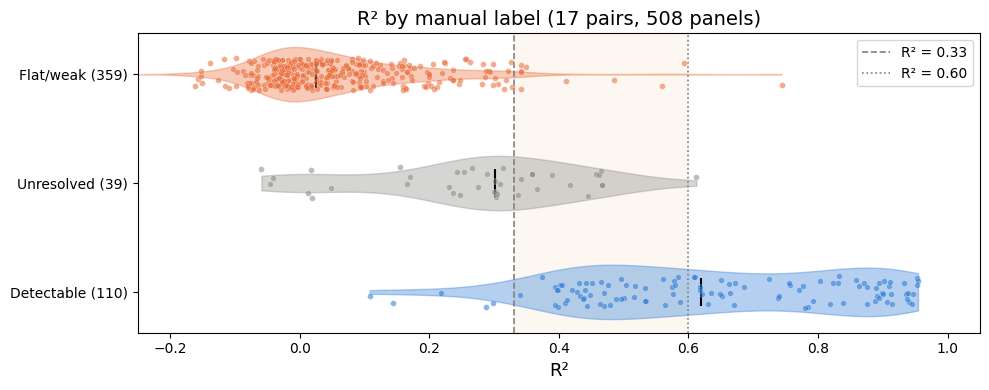

  Detectable  : n=110  median=0.619  [0.108, 0.954]
  Unresolved  : n= 39  median=0.301  [-0.059, 0.612]
  Flat/weak   : n=359  median=0.026  [-0.529, 0.744]


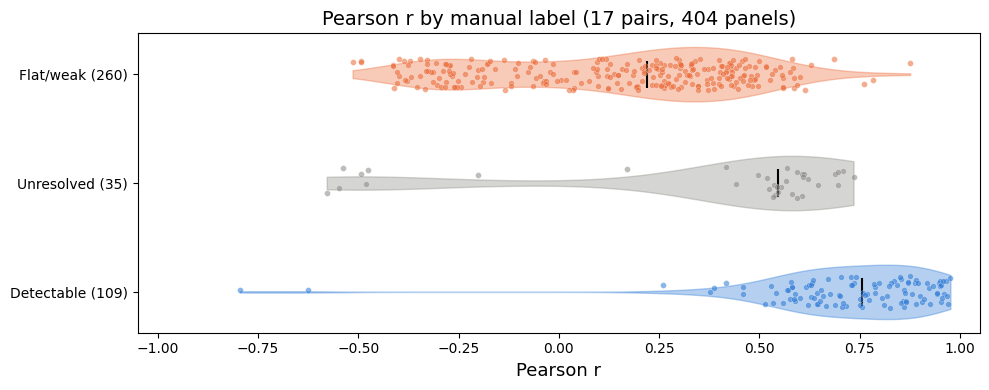

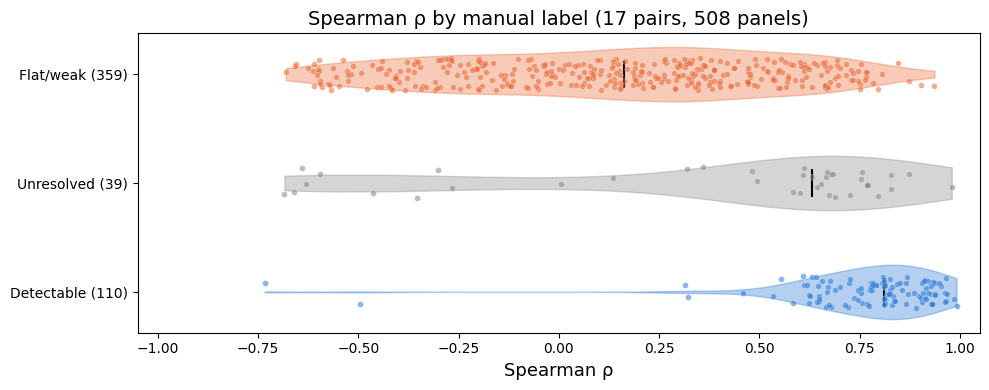

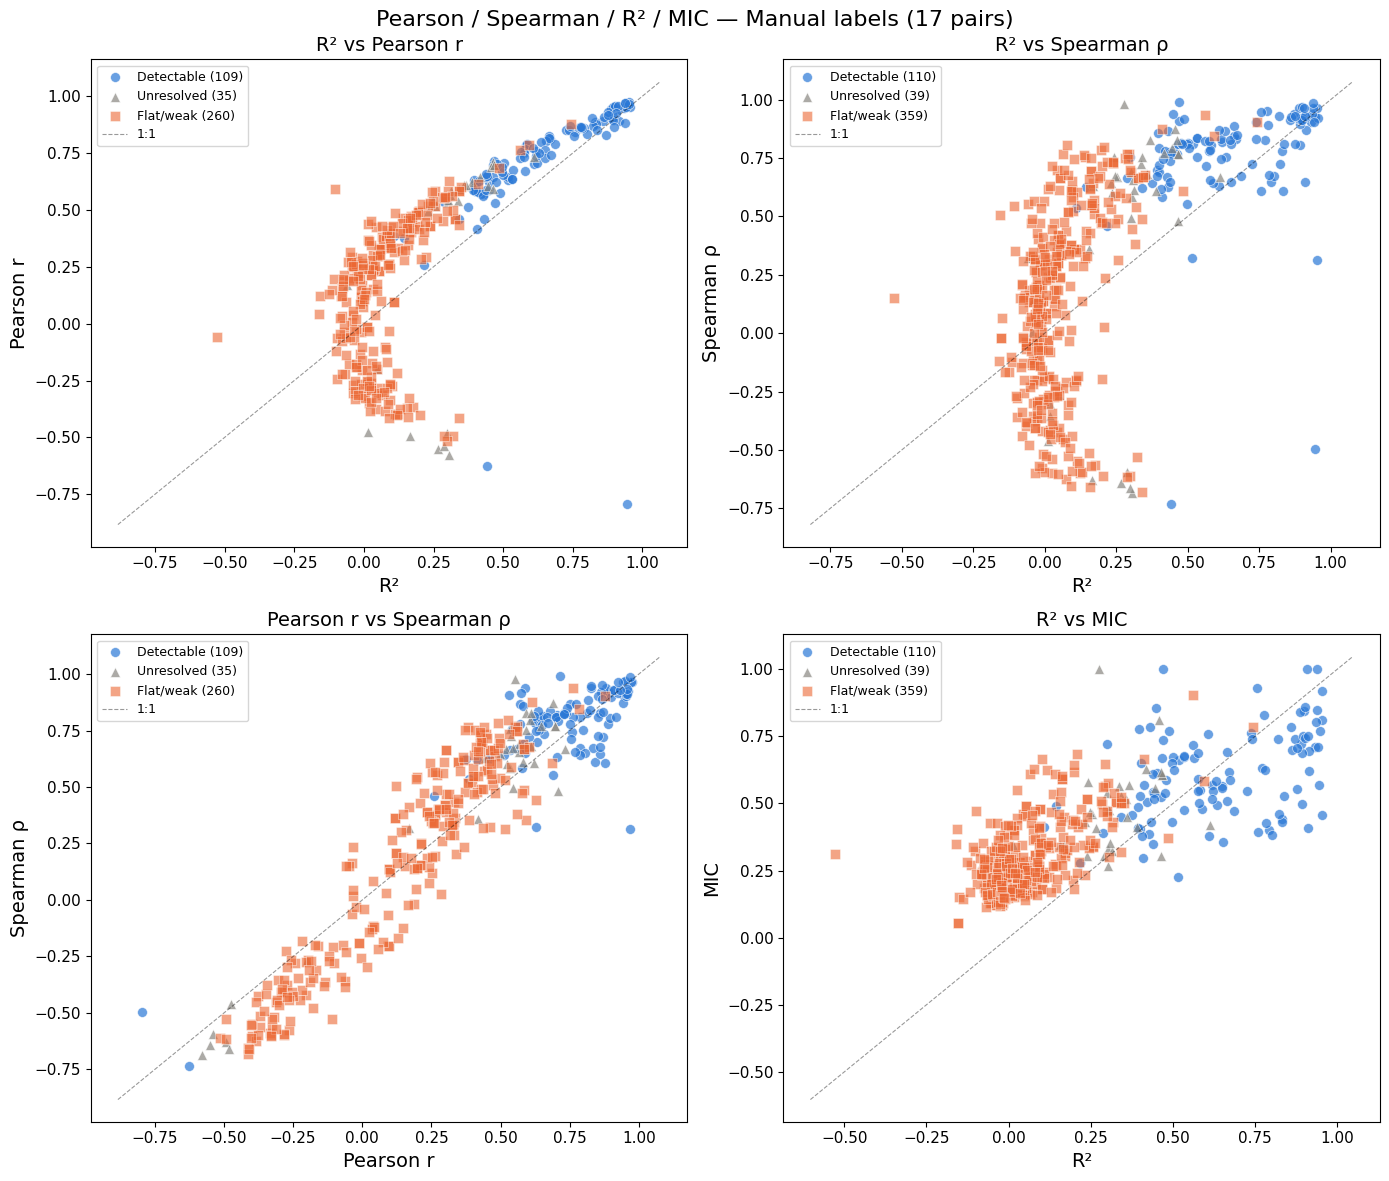


── Metric correlations (Pearson) ──
  r2           vs pearson_r     r = 0.726  (n=404)
  r2           vs spearman_r    r = 0.630  (n=508)
  pearson_r    vs spearman_r    r = 0.942  (n=404)
  r2           vs mic           r = 0.779  (n=508)


In [57]:
# --- Comprehensive manual-label diagnostics: all labelled pairs ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl

# ── 1. Load feature table ──
feat = pd.read_csv('output/S4.3_1e-2/lowess_panel_features.csv')

# ── 2. Load Overall response strength from ALL sheets ──
label_path = 'label/CMIP6_mean_shape_manual_labels_new.xlsx'
models = ['CESM2', 'CNRM-CM6-1', 'CanESM5', 'GFDL-CM4', 'CMCC-CM2-SR5']
zones  = ['all_land', 'WW', 'WD', 'CW', 'CD', 'LI']

all_sheets = {
    'P_Q': 'P → Q', 'ET_Q': 'ET → Q', 'tran_Q': 'tran → Q',
    'mrros_Q': 'mrros → Q', 'tas_Q': 'tas → Q', 'prsn_Q': 'prsn → Q',
    'evspsblsoi_Q': 'evspsblsoi → Q', 'hfls_Q': 'hfls → Q',
    'hfss_Q': 'hfss → Q', 'lai_Q': 'lai → Q', 'rsds_Q': 'rsds → Q',
    'mrso_Q': 'mrso → Q', 'mrsos_Q': 'mrsos → Q',
    'rlds_Q': 'rlds → Q', 'rlus_Q': 'rlus → Q', 'rsus_Q': 'rsus → Q',
    'P_ET': 'P → ET',
}

label_map = {}
wb = openpyxl.load_workbook(label_path, read_only=True)
for sheet, pair_name in all_sheets.items():
    if sheet not in wb.sheetnames:
        continue
    ws = wb[sheet]
    for i, m in enumerate(models):
        for j, z in enumerate(zones):
            val = ws.cell(5 + i, 2 + j).value
            if val and str(val).strip():
                label_map[(pair_name, m, z)] = str(val).strip()
wb.close()

# ── 3. Merge ──
pairs_with_labels = sorted(set(p for (p, _, _) in label_map.keys()))
df = feat[feat['Pair'].isin(pairs_with_labels)].copy()
df['manual_label'] = df.apply(
    lambda r: label_map.get((r['Pair'], r['Model'], r['Zone']), None), axis=1
)
df = df.dropna(subset=['manual_label', 'r2'])
df = df[~df['manual_label'].isin(['Insufficient data'])]

n_pairs = len(pairs_with_labels)
n_total = len(df)
print(f'Pairs with labels: {n_pairs}')
print(f'Total labelled panels: {n_total}')
print(df['manual_label'].value_counts().to_string())

label_order = ['Detectable', 'Unresolved', 'Flat/weak']
colors = {'Detectable': '#2a78d6', 'Unresolved': '#898781', 'Flat/weak': '#eb6834'}

# ── Helper ──
def plot_violin(ax, df, metric, xlabel, title):
    data = [df.loc[df['manual_label'] == lab, metric].dropna().values
            for lab in label_order]
    parts = ax.violinplot(data, positions=range(len(label_order)),
                          vert=False, showmedians=True, showextrema=False)
    for body, lab in zip(parts['bodies'], label_order):
        body.set_facecolor(colors[lab])
        body.set_alpha(0.35)
        body.set_edgecolor(colors[lab])
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1.5)
    for i, lab in enumerate(label_order):
        vals = df.loc[df['manual_label'] == lab, metric].dropna().values
        jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(vals))
        ax.scatter(vals, i + jitter, c=colors[lab], s=18, alpha=0.55,
                   edgecolors='white', linewidths=0.3, zorder=3)
    ax.set_yticks(range(len(label_order)))
    ax.set_yticklabels(
        [f'{lab} ({len(d)})' for lab, d in zip(label_order, data)],
        fontsize=12)
    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_title(title, fontsize=14)
    ax.tick_params(labelsize=10)
    return data

# ═══════════════════════════════════════════
# A. R² violin
# ═══════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 4))
data = plot_violin(ax, df, 'r2', 'R²',
                   f'R² by manual label ({n_pairs} pairs, {n_total} panels)')
ax.axvline(0.33, color='gray', ls='--', lw=1.2, label='R² = 0.33')
ax.axvline(0.60, color='gray', ls=':',  lw=1.2, label='R² = 0.60')
ax.axvspan(0.33, 0.60, color='#F5E6C8', alpha=0.25, zorder=0)
ax.set_xlim(-0.25, 1.05)
ax.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()
for lab, d in zip(label_order, data):
    if len(d):
        print(f'  {lab:12s}: n={len(d):3d}  median={np.median(d):.3f}  '
              f'[{np.min(d):.3f}, {np.max(d):.3f}]')

# ═══════════════════════════════════════════
# B. Pearson r violin
# ═══════════════════════════════════════════
df_pr = df.dropna(subset=['pearson_r'])
fig, ax = plt.subplots(figsize=(10, 4))
plot_violin(ax, df_pr, 'pearson_r', 'Pearson r',
            f'Pearson r by manual label ({n_pairs} pairs, {len(df_pr)} panels)')
ax.set_xlim(-1.05, 1.05)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════
# C. Spearman ρ violin
# ═══════════════════════════════════════════
df_sp = df.dropna(subset=['spearman_r'])
fig, ax = plt.subplots(figsize=(10, 4))
plot_violin(ax, df_sp, 'spearman_r', 'Spearman ρ',
            f'Spearman ρ by manual label ({n_pairs} pairs, {len(df_sp)} panels)')
ax.set_xlim(-1.05, 1.05)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════
# D. Four-panel scatter
# ═══════════════════════════════════════════
label_style = {
    'Detectable':  {'c': '#2a78d6', 'marker': 'o', 'alpha': 0.7},
    'Flat/weak':   {'c': '#eb6834', 'marker': 's', 'alpha': 0.6},
    'Unresolved':  {'c': '#898781', 'marker': '^', 'alpha': 0.7},
}

metric_pairs = [
    ('r2',        'pearson_r',  'R²',        'Pearson r'),
    ('r2',        'spearman_r', 'R²',        'Spearman ρ'),
    ('pearson_r', 'spearman_r', 'Pearson r',  'Spearman ρ'),
    ('r2',        'mic',        'R²',        'MIC'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()
for ax, (xcol, ycol, xlab, ylab) in zip(axes, metric_pairs):
    for label in label_order:
        style = label_style[label]
        sub = df[df['manual_label'] == label].dropna(subset=[xcol, ycol])
        if len(sub) == 0:
            continue
        ax.scatter(sub[xcol], sub[ycol],
                   c=style['c'], marker=style['marker'], alpha=style['alpha'],
                   s=50, edgecolors='white', linewidths=0.5,
                   label=f"{label} ({len(sub)})")
    lo = min(ax.get_xlim()[0], ax.get_ylim()[0])
    hi = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.4, label='1:1')
    ax.set_xlabel(xlab, fontsize=14)
    ax.set_ylabel(ylab, fontsize=14)
    ax.legend(fontsize=9, loc='upper left')
    ax.tick_params(labelsize=11)
    ax.set_title(f'{xlab} vs {ylab}', fontsize=14)

fig.suptitle(
    f'Pearson / Spearman / R² / MIC — Manual labels ({n_pairs} pairs)',
    fontsize=16)
plt.tight_layout()
plt.show()

print('\n── Metric correlations (Pearson) ──')
for a, b in [('r2', 'pearson_r'), ('r2', 'spearman_r'),
             ('pearson_r', 'spearman_r'), ('r2', 'mic')]:
    valid = df[[a, b]].dropna()
    r = valid[a].corr(valid[b])
    print(f'  {a:12s} vs {b:12s}  r = {r:.3f}  (n={len(valid)})')
